# Statistics & Probability for Data Science Interviews
## Complete Interview Preparation Guide

This notebook covers every major statistics and probability topic tested in data science interviews.

**Topics Covered:**
1. Descriptive Statistics Deep Dive
2. Probability Distributions
3. Central Limit Theorem
4. Hypothesis Testing
5. t-test, Chi-Square, ANOVA
6. Confidence Intervals
7. Correlation vs Causation
8. Bayes' Theorem
9. Expected Value and Variance
10. A/B Testing Framework
11. Sampling Methods
12. Common Interview Traps

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import (norm, binom, poisson, uniform, expon,
                         t as t_dist, chi2, f as f_dist,
                         pearsonr, spearmanr, kendalltau)
import warnings
warnings.filterwarnings('ignore')

# Plotting defaults
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')
np.random.seed(42)
print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## 1. Descriptive Statistics Deep Dive

### Key Formulas

**Mean:** $\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$

**Variance:** $s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2$

**Skewness:** $\gamma_1 = \frac{1}{n}\sum\left(\frac{x_i-\bar{x}}{s}\right)^3$

**Kurtosis (excess):** $\gamma_2 = \frac{1}{n}\sum\left(\frac{x_i-\bar{x}}{s}\right)^4 - 3$

---

> **When to use each central tendency measure:**
> - **Mean** — symmetric distributions with no outliers
> - **Median** — skewed distributions, outliers present (income, house prices)
> - **Mode** — categorical data, or finding the most frequent value

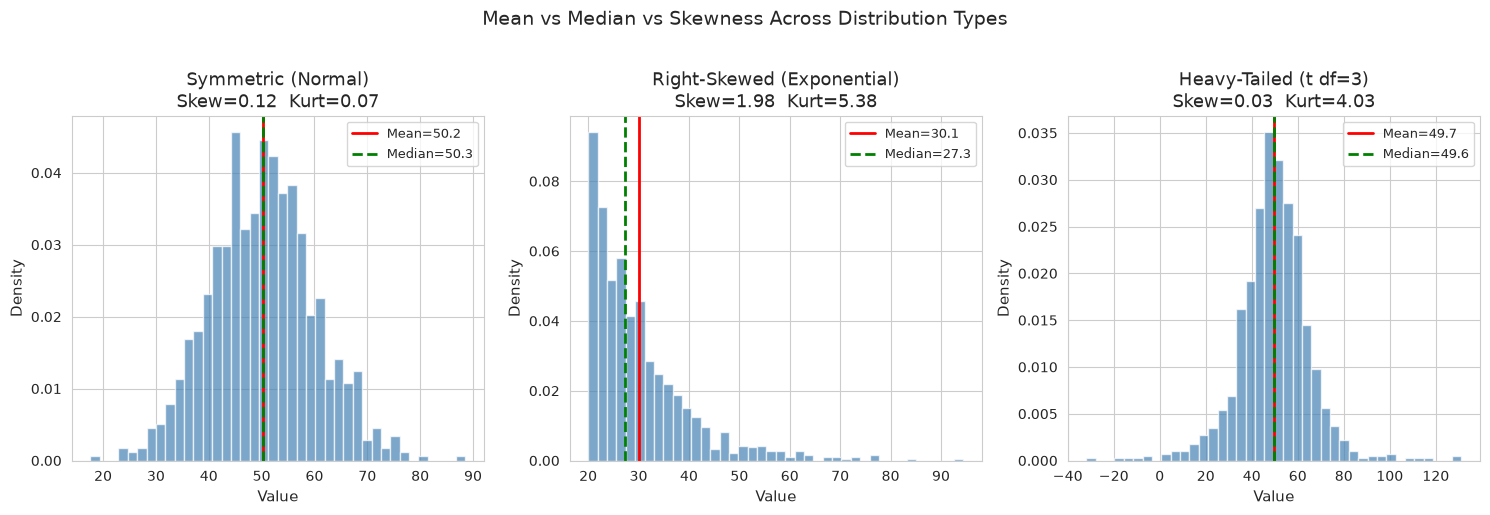


=== Descriptive Statistics Summary ===
Metric                       Symmetric   Right-Skewed   Heavy-Tailed
--------------------------------------------------------------------
Mean                            50.193         30.080         49.677
Median                          50.253         27.259         49.646
Std Dev                          9.787         10.025         15.384
Skewness                         0.117          1.981          0.028
Kurtosis (excess)                0.066          5.379          4.029


In [2]:
# ── Descriptive Statistics Deep Dive ──
from scipy.stats import skew, kurtosis

np.random.seed(42)

# Three datasets: symmetric, right-skewed, heavy-tailed
symmetric   = np.random.normal(50, 10, 1000)
right_skewed = np.random.exponential(scale=10, size=1000) + 20   # positive skew
heavy_tailed = np.random.standard_t(df=3, size=1000) * 10 + 50   # high kurtosis

datasets = {'Symmetric (Normal)': symmetric,
            'Right-Skewed (Exponential)': right_skewed,
            'Heavy-Tailed (t df=3)': heavy_tailed}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, data) in zip(axes, datasets.items()):
    ax.hist(data, bins=40, color='steelblue', alpha=0.7, edgecolor='white', density=True)
    ax.axvline(np.mean(data), color='red',    lw=2, linestyle='-',  label=f'Mean={np.mean(data):.1f}')
    ax.axvline(np.median(data), color='green', lw=2, linestyle='--', label=f'Median={np.median(data):.1f}')
    ax.set_title(f'{name}\nSkew={skew(data):.2f}  Kurt={kurtosis(data):.2f}')
    ax.legend(fontsize=9)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')

plt.suptitle('Mean vs Median vs Skewness Across Distribution Types', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Summary table
print("\n=== Descriptive Statistics Summary ===")
print(f"{'Metric':<25} {'Symmetric':>12} {'Right-Skewed':>14} {'Heavy-Tailed':>14}")
print("-" * 68)
for label, fn in [('Mean', np.mean), ('Median', np.median),
                  ('Std Dev', np.std), ('Skewness', skew), ('Kurtosis (excess)', kurtosis)]:
    vals = [fn(d) for d in datasets.values()]
    print(f"{label:<25} {vals[0]:>12.3f} {vals[1]:>14.3f} {vals[2]:>14.3f}")

### INTERVIEW QUESTION 1
**Q: When should you use median instead of mean? Why does this matter in ML?**

**A:**
Use **median** when data is skewed or contains outliers — house prices, salaries, response times.
The mean is sensitive to outliers (one extreme value shifts it dramatically), while median is robust.

**In ML this matters because:**
- Using mean to impute missing values in skewed features can distort model inputs; prefer median imputation
- Loss functions: MSE minimizes mean, MAE minimizes median — for skewed targets, MAE/Huber loss is often better
- Feature scaling: StandardScaler uses mean/std, which are non-robust; RobustScaler uses median/IQR instead

**Skewness rule of thumb:**
- |skew| < 0.5 → roughly symmetric → mean ≈ median
- 0.5 < |skew| < 1 → moderate skew → consider log transform
- |skew| > 1 → high skew → median preferred, consider Box-Cox/log transform

---
## 2. Probability Distributions

| Distribution | Type | Key Parameters | Real-World Use |
|---|---|---|---|
| Normal | Continuous | μ, σ | Heights, errors, CLT limit |
| Binomial | Discrete | n, p | Click-through rates, A/B tests |
| Poisson | Discrete | λ | Event counts per time unit |
| Exponential | Continuous | λ | Time between events |
| Uniform | Continuous | a, b | Random number generation |

**Normal PDF:** $f(x) = \frac{1}{\sigma\sqrt{2\pi}}e^{-\frac{(x-\mu)^2}{2\sigma^2}}$

**Binomial PMF:** $P(X=k) = \binom{n}{k}p^k(1-p)^{n-k}$

**Poisson PMF:** $P(X=k) = \frac{\lambda^k e^{-\lambda}}{k!}$

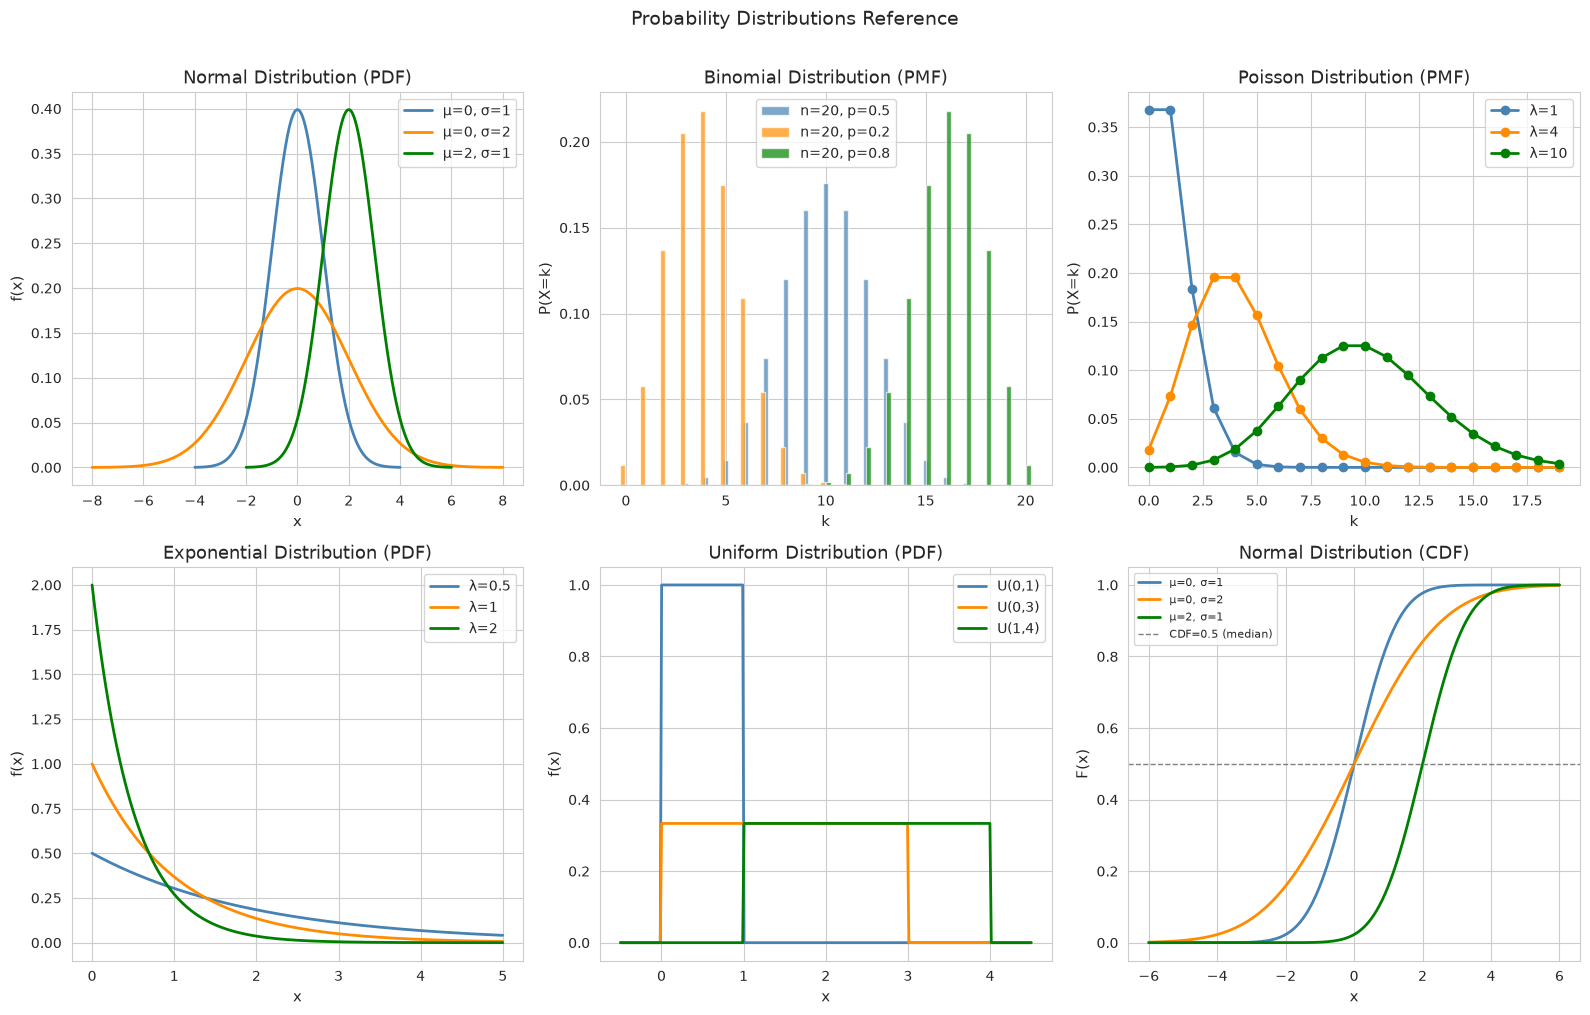

In [3]:
# ── Probability Distributions ──
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Normal
x = np.linspace(-4, 4, 300)
for mu, sigma, label in [(0,1,'μ=0,σ=1'), (0,2,'μ=0,σ=2'), (2,1,'μ=2,σ=1')]:
    axes[0,0].plot(x*sigma + mu if sigma!=1 or mu!=0 else x,
                   norm.pdf(x), label=label)
# redo properly
axes[0,0].cla()
for mu, sigma, color in [(0,1,'steelblue'), (0,2,'darkorange'), (2,1,'green')]:
    xr = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
    axes[0,0].plot(xr, norm.pdf(xr, mu, sigma), lw=2, label=f'μ={mu}, σ={sigma}', color=color)
axes[0,0].set_title('Normal Distribution (PDF)')
axes[0,0].legend(); axes[0,0].set_xlabel('x'); axes[0,0].set_ylabel('f(x)')

# 2. Binomial
k = np.arange(0, 21)
for n, p, color in [(20,0.5,'steelblue'), (20,0.2,'darkorange'), (20,0.8,'green')]:
    axes[0,1].bar(k + (p-0.5)*0.5, binom.pmf(k, n, p), width=0.25,
                  alpha=0.7, label=f'n={n}, p={p}', color=color)
axes[0,1].set_title('Binomial Distribution (PMF)')
axes[0,1].legend(); axes[0,1].set_xlabel('k'); axes[0,1].set_ylabel('P(X=k)')

# 3. Poisson
k = np.arange(0, 20)
for lam, color in [(1,'steelblue'), (4,'darkorange'), (10,'green')]:
    axes[0,2].plot(k, poisson.pmf(k, lam), 'o-', lw=2, label=f'λ={lam}', color=color)
axes[0,2].set_title('Poisson Distribution (PMF)')
axes[0,2].legend(); axes[0,2].set_xlabel('k'); axes[0,2].set_ylabel('P(X=k)')

# 4. Exponential
x = np.linspace(0, 5, 300)
for lam, color in [(0.5,'steelblue'), (1,'darkorange'), (2,'green')]:
    axes[1,0].plot(x, expon.pdf(x, scale=1/lam), lw=2, label=f'λ={lam}', color=color)
axes[1,0].set_title('Exponential Distribution (PDF)')
axes[1,0].legend(); axes[1,0].set_xlabel('x'); axes[1,0].set_ylabel('f(x)')

# 5. Uniform
x = np.linspace(-0.5, 4.5, 300)
for a, b, color in [(0,1,'steelblue'), (0,3,'darkorange'), (1,4,'green')]:
    axes[1,1].plot(x, uniform.pdf(x, a, b-a), lw=2, label=f'U({a},{b})', color=color)
axes[1,1].set_title('Uniform Distribution (PDF)')
axes[1,1].legend(); axes[1,1].set_xlabel('x'); axes[1,1].set_ylabel('f(x)')

# 6. CDF comparison for Normal
x = np.linspace(-4, 4, 300)
for mu, sigma, color in [(0,1,'steelblue'), (0,2,'darkorange'), (2,1,'green')]:
    xr = np.linspace(-6, 6, 300)
    axes[1,2].plot(xr, norm.cdf(xr, mu, sigma), lw=2,
                   label=f'μ={mu}, σ={sigma}', color=color)
axes[1,2].axhline(0.5, color='gray', linestyle='--', lw=1, label='CDF=0.5 (median)')
axes[1,2].set_title('Normal Distribution (CDF)')
axes[1,2].legend(fontsize=8); axes[1,2].set_xlabel('x'); axes[1,2].set_ylabel('F(x)')

plt.suptitle('Probability Distributions Reference', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [4]:
# Scipy.stats practical usage
print("=== scipy.stats Practical Examples ===\n")

# Normal: What % of data is within 2 std devs?
p_within_2sigma = norm.cdf(2) - norm.cdf(-2)
print(f"P(-2σ < X < 2σ) for Normal = {p_within_2sigma:.4f} ({p_within_2sigma*100:.2f}%)")
print(f"P(-1σ < X < 1σ) = {(norm.cdf(1)-norm.cdf(-1))*100:.2f}%")
print(f"P(-3σ < X < 3σ) = {(norm.cdf(3)-norm.cdf(-3))*100:.4f}%  (6-sigma = 99.9997%)")

# Binomial: CTR problem
n, p = 1000, 0.05   # 1000 visitors, 5% expected CTR
print(f"\nBinomial(n=1000, p=0.05):")
print(f"  E[X] = np = {n*p:.0f} clicks")
print(f"  P(X >= 60) = {1 - binom.cdf(59, n, p):.4f}")
print(f"  P(40 <= X <= 60) = {binom.cdf(60,n,p) - binom.cdf(39,n,p):.4f}")

# Poisson: server requests
lam = 10  # avg 10 requests/second
print(f"\nPoisson(λ=10 requests/sec):")
print(f"  P(X = 10) = {poisson.pmf(10, lam):.4f}")
print(f"  P(X > 15) = {1 - poisson.cdf(15, lam):.4f}  (overload probability)")

# Exponential: time between failures
scale = 100  # avg 100 hours between failures
print(f"\nExponential(mean=100 hours):")
print(f"  P(failure within 50 hrs) = {expon.cdf(50, scale=scale):.4f}")
print(f"  Median time to failure = {expon.ppf(0.5, scale=scale):.2f} hrs")

=== scipy.stats Practical Examples ===

P(-2σ < X < 2σ) for Normal = 0.9545 (95.45%)
P(-1σ < X < 1σ) = 68.27%
P(-3σ < X < 3σ) = 99.7300%  (6-sigma = 99.9997%)

Binomial(n=1000, p=0.05):
  E[X] = np = 50 clicks
  P(X >= 60) = 0.0867
  P(40 <= X <= 60) = 0.8731

Poisson(λ=10 requests/sec):
  P(X = 10) = 0.1251
  P(X > 15) = 0.0487  (overload probability)

Exponential(mean=100 hours):
  P(failure within 50 hrs) = 0.3935
  Median time to failure = 69.31 hrs


### INTERVIEW QUESTION 2
**Q: What distribution would you use to model: (a) number of customer support tickets per hour, (b) time until next purchase, (c) whether a user clicks an ad?**

**A:**
- **(a) Support tickets per hour** → **Poisson** — counts of rare, independent events in a fixed time window. Parameter λ = average rate. Check: mean ≈ variance (overdispersion → Negative Binomial)
- **(b) Time until next purchase** → **Exponential** — memoryless waiting time between Poisson events. If times cluster (not memoryless), use **Weibull**
- **(c) Ad click** → **Bernoulli** (single trial) or **Binomial** (n impressions). CTR = p parameter

**Key insight for interviews:** Poisson and Exponential are conjugates — if counts follow Poisson(λ), inter-arrival times follow Exponential(1/λ).

---
## 3. Central Limit Theorem (CLT)

**Statement:** For independent, identically distributed random variables $X_1, X_2, \ldots, X_n$ with mean $\mu$ and finite variance $\sigma^2$:

$$\frac{\bar{X}_n - \mu}{\sigma/\sqrt{n}} \xrightarrow{d} N(0, 1) \quad \text{as } n \to \infty$$

**In plain English:** The sampling distribution of the sample mean becomes approximately Normal, regardless of the original population's distribution, as sample size grows.

**Why it matters for ML:**
- Justifies using Normal-based confidence intervals
- Underpins z-tests and t-tests
- Explains why many ML algorithms converge (average of many weak signals)
- Bootstrap and permutation tests rely on CLT intuition

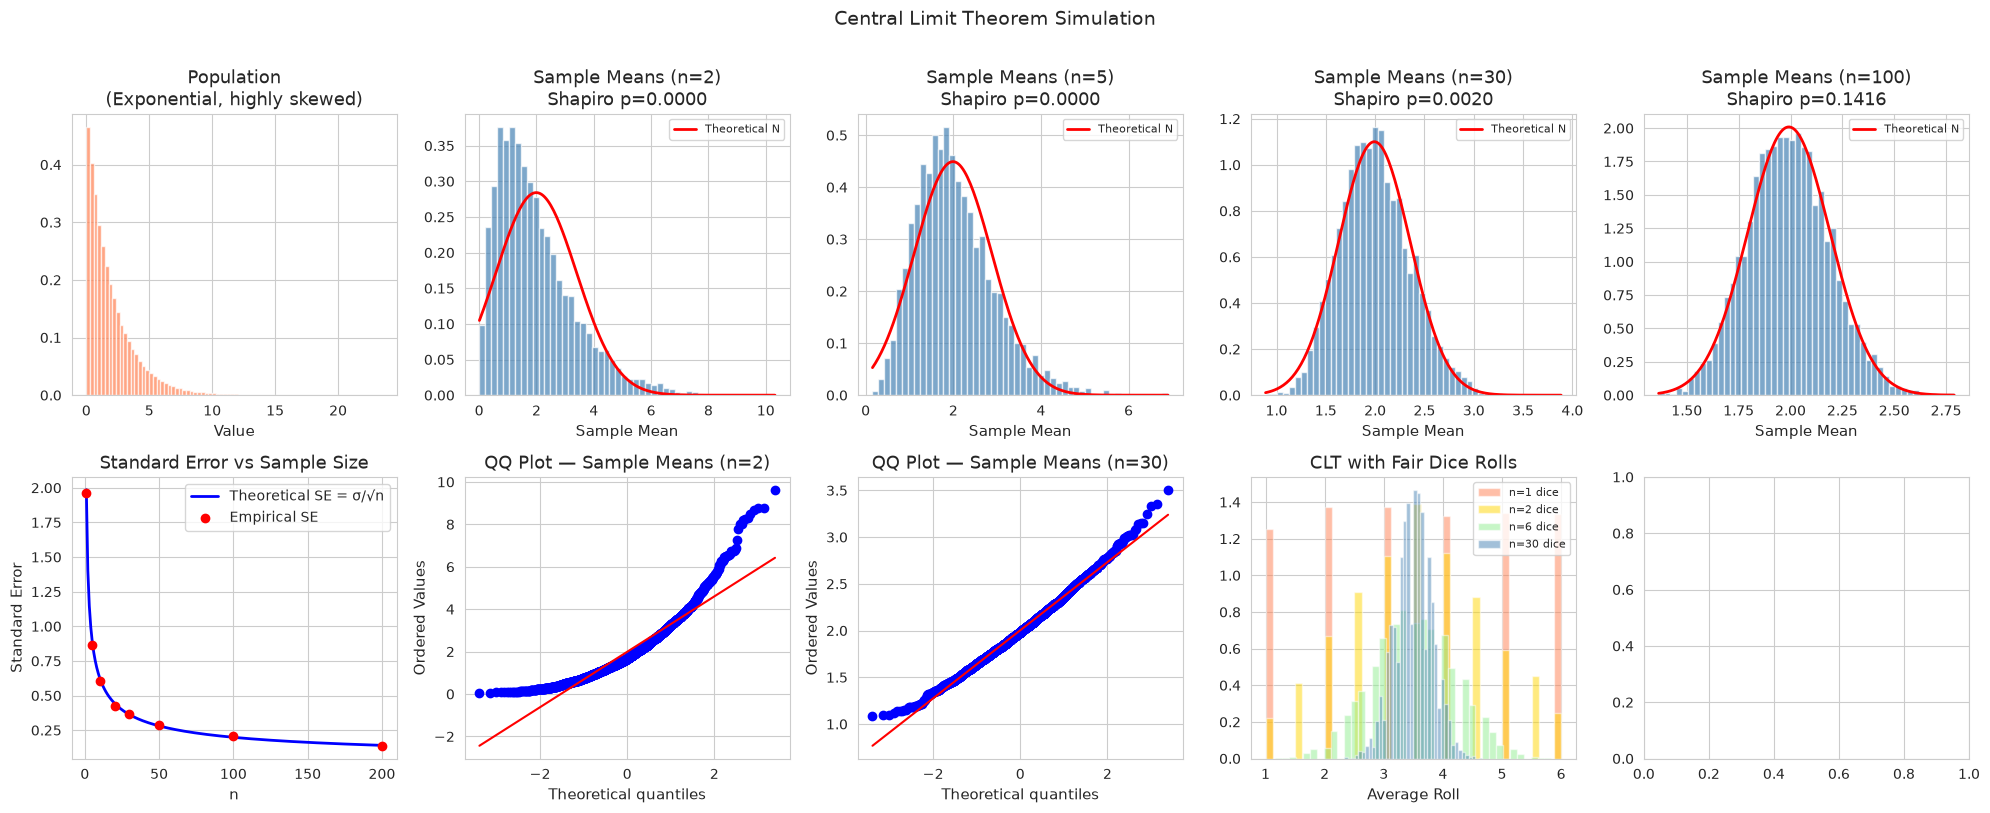

Population mean: 1.9919
Population std:  1.9859
SE for n=30:     0.3626
SE for n=100:    0.1986


In [5]:
# ── CLT Simulation ──
np.random.seed(42)

# Population: extremely non-normal (exponential)
population = np.random.exponential(scale=2, size=100_000)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

# Row 0: Population and sampling distributions for different n
axes[0, 0].hist(population, bins=80, color='coral', alpha=0.7, density=True, edgecolor='white')
axes[0, 0].set_title('Population\n(Exponential, highly skewed)')
axes[0, 0].set_xlabel('Value')

sample_sizes = [2, 5, 30, 100]
for i, n in enumerate(sample_sizes):
    sample_means = [np.mean(np.random.choice(population, size=n)) for _ in range(5000)]
    ax = axes[0, i + 0] if i == 0 else axes[0, i]
    ax = axes[0, i + 1]   # shift by 1 for population plot
    ax.hist(sample_means, bins=50, color='steelblue', alpha=0.7, density=True, edgecolor='white')
    # Overlay theoretical normal
    mu_theory = np.mean(population)
    sigma_theory = np.std(population) / np.sqrt(n)
    x_range = np.linspace(min(sample_means), max(sample_means), 200)
    ax.plot(x_range, norm.pdf(x_range, mu_theory, sigma_theory), 'r-', lw=2, label='Theoretical N')
    # Normality test
    _, p_sw = stats.shapiro(np.random.choice(sample_means, 500))
    ax.set_title(f'Sample Means (n={n})\nShapiro p={p_sw:.4f}')
    ax.set_xlabel('Sample Mean')
    ax.legend(fontsize=8)

# Row 1: Show SE shrinks with sqrt(n)
ns = np.arange(1, 201)
theoretical_se = np.std(population) / np.sqrt(ns)
empirical_se = [np.std([np.mean(np.random.choice(population, n)) for _ in range(1000)]) for n in [1,5,10,20,30,50,100,200]]
axes[1, 0].plot(ns, theoretical_se, 'b-', lw=2, label='Theoretical SE = σ/√n')
axes[1, 0].scatter([1,5,10,20,30,50,100,200], empirical_se, color='red', zorder=5, label='Empirical SE')
axes[1, 0].set_title('Standard Error vs Sample Size')
axes[1, 0].set_xlabel('n'); axes[1, 0].set_ylabel('Standard Error')
axes[1, 0].legend()

# QQ plots for n=2 and n=30
for col, n in [(1, 2), (2, 30)]:
    sample_means = [np.mean(np.random.choice(population, n)) for _ in range(2000)]
    stats.probplot(sample_means, plot=axes[1, col])
    axes[1, col].set_title(f'QQ Plot — Sample Means (n={n})')

# CLT with dice rolls
n_dice = [1, 2, 6, 30]
colors = ['coral', 'gold', 'lightgreen', 'steelblue']
for col, (n, c) in enumerate(zip(n_dice, colors)):
    means = [np.mean(np.random.randint(1, 7, n)) for _ in range(5000)]
    axes[1, 3].hist(means, bins=40, alpha=0.5, label=f'n={n} dice', color=c, density=True)
axes[1, 3].set_title('CLT with Fair Dice Rolls')
axes[1, 3].legend(fontsize=8); axes[1, 3].set_xlabel('Average Roll')

plt.suptitle('Central Limit Theorem Simulation', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"Population mean: {np.mean(population):.4f}")
print(f"Population std:  {np.std(population):.4f}")
print(f"SE for n=30:     {np.std(population)/np.sqrt(30):.4f}")
print(f"SE for n=100:    {np.std(population)/np.sqrt(100):.4f}")

### INTERVIEW QUESTION 3
**Q: What does the CLT say, and what does it NOT say? When does it break down?**

**A:**

**What it says:** The *sampling distribution of the sample mean* approaches Normal as n → ∞, regardless of population shape.

**What it does NOT say:**
- It does NOT say the population becomes Normal
- It does NOT say individual sample data becomes Normal
- It does NOT guarantee fast convergence for all distributions

**When it breaks down:**
1. **Non-finite variance** — Cauchy distribution has no finite variance; CLT doesn't apply
2. **Very small n** — Rule of thumb: n ≥ 30 for mild skew; n ≥ 100+ for heavy tails
3. **Non-independent samples** — time series autocorrelation violates the iid assumption
4. **Heavy-tailed distributions** — Pareto/power laws converge very slowly

**Interview insight:** "If the population is Normal, the sampling distribution of $\bar{X}$ is *exactly* Normal for any n — CLT isn't even needed there."

---
## 4. Hypothesis Testing Framework

### Key Concepts

| Term | Definition |
|---|---|
| **Null hypothesis H₀** | Default assumption (no effect, no difference) |
| **Alternative H₁** | What you want to detect |
| **p-value** | P(observing data this extreme \| H₀ is true) |
| **α (significance level)** | Threshold for rejecting H₀ (usually 0.05) |
| **Type I Error (α)** | Reject H₀ when it's actually true (false positive) |
| **Type II Error (β)** | Fail to reject H₀ when H₁ is true (false negative) |
| **Power (1-β)** | Probability of correctly detecting a real effect |

$$\text{p-value} = P(T \geq t_{obs} \mid H_0 \text{ true})$$

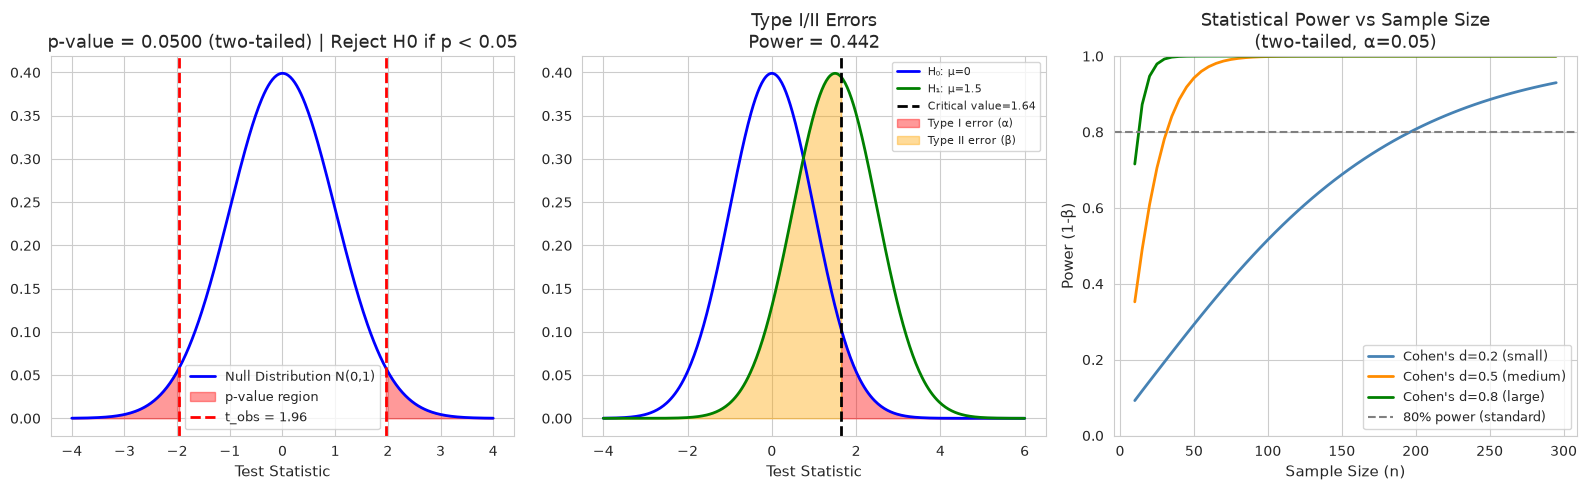

Simulated false positive rate (α=0.05): 0.0496
Expected: ~0.0500


In [6]:
# ── Hypothesis Testing Simulation ──
np.random.seed(42)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Visualize p-value concept
mu0, sigma = 0, 1
t_obs = 1.96
x = np.linspace(-4, 4, 400)

axes[0].plot(x, norm.pdf(x), 'b-', lw=2, label='Null Distribution N(0,1)')
# Shade rejection region (two-tailed)
x_right = np.linspace(t_obs, 4, 200)
x_left  = np.linspace(-4, -t_obs, 200)
axes[0].fill_between(x_right, norm.pdf(x_right), alpha=0.4, color='red', label=f'p-value region')
axes[0].fill_between(x_left,  norm.pdf(x_left),  alpha=0.4, color='red')
axes[0].axvline(t_obs, color='red', lw=2, linestyle='--', label=f't_obs = {t_obs}')
axes[0].axvline(-t_obs, color='red', lw=2, linestyle='--')
p_val = 2 * (1 - norm.cdf(t_obs))
axes[0].set_title(f'p-value = {p_val:.4f} (two-tailed) | Reject H0 if p < 0.05')
axes[0].legend(fontsize=9); axes[0].set_xlabel('Test Statistic')

# 2. Type I and Type II Errors
delta = 1.5  # true effect
x = np.linspace(-4, 6, 400)
null_dist = norm.pdf(x, 0, 1)
alt_dist  = norm.pdf(x, delta, 1)
critical  = norm.ppf(0.95)   # one-tailed α=0.05

axes[1].plot(x, null_dist, 'b-', lw=2, label='H₀: μ=0')
axes[1].plot(x, alt_dist,  'g-', lw=2, label=f'H₁: μ={delta}')
axes[1].axvline(critical, color='black', linestyle='--', lw=2, label=f'Critical value={critical:.2f}')

# Type I (false positive)
x_alpha = np.linspace(critical, 6, 200)
axes[1].fill_between(x_alpha, norm.pdf(x_alpha, 0, 1), alpha=0.4, color='red', label='Type I error (α)')

# Type II (false negative)
x_beta = np.linspace(-4, critical, 200)
axes[1].fill_between(x_beta, norm.pdf(x_beta, delta, 1), alpha=0.4, color='orange', label='Type II error (β)')

power = 1 - norm.cdf(critical, delta, 1)
axes[1].set_title(f'Type I/II Errors\nPower = {power:.3f}')
axes[1].legend(fontsize=8); axes[1].set_xlabel('Test Statistic')

# 3. Power vs sample size
effect_sizes = [0.2, 0.5, 0.8]   # Cohen's d: small, medium, large
ns = np.arange(10, 300, 5)
colors3 = ['steelblue', 'darkorange', 'green']
for d, c in zip(effect_sizes, colors3):
    powers = []
    for n in ns:
        se = 1 / np.sqrt(n)
        crit = norm.ppf(0.975) * se  # two-tailed α=0.05
        power = 1 - norm.cdf(crit, loc=d*se*np.sqrt(n), scale=se) + norm.cdf(-crit, loc=d*se*np.sqrt(n), scale=se)
        # Simpler: non-centrality parameter
        ncp = d * np.sqrt(n)
        power2 = norm.cdf(ncp - 1.96) + norm.cdf(-ncp - 1.96)
        powers.append(norm.cdf(ncp - 1.96))
    axes[2].plot(ns, powers, lw=2, color=c, label=f"Cohen's d={d} ({'small' if d<0.3 else 'medium' if d<0.6 else 'large'})")

axes[2].axhline(0.8, color='gray', linestyle='--', lw=1.5, label='80% power (standard)')
axes[2].set_title('Statistical Power vs Sample Size\n(two-tailed, α=0.05)')
axes[2].set_xlabel('Sample Size (n)'); axes[2].set_ylabel('Power (1-β)')
axes[2].legend(fontsize=9); axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Simulation: demonstrate false positive rate
np.random.seed(0)
n_experiments = 10000
alpha = 0.05
false_positives = 0
for _ in range(n_experiments):
    # Both groups truly from same distribution (H0 true)
    group_a = np.random.normal(0, 1, 50)
    group_b = np.random.normal(0, 1, 50)
    _, p = stats.ttest_ind(group_a, group_b)
    if p < alpha:
        false_positives += 1

print(f"Simulated false positive rate (α=0.05): {false_positives/n_experiments:.4f}")
print(f"Expected: ~0.0500")

### INTERVIEW QUESTION 4
**Q: What is a p-value? What are the most common misinterpretations?**

**A:**

**Correct definition:** The p-value is the probability of observing a test statistic as extreme as (or more extreme than) the observed value, *assuming the null hypothesis is true*.

$$p = P(|T| \geq |t_{obs}| \mid H_0)$$

**Common WRONG interpretations (huge interview trap):**
1. ❌ "p = 0.03 means there's a 3% chance H₀ is true" — WRONG. p-value says nothing about P(H₀ true)
2. ❌ "p < 0.05 means the result is important or large" — WRONG. Statistical ≠ practical significance
3. ❌ "p = 0.06 means no effect" — WRONG. Absence of evidence ≠ evidence of absence
4. ❌ "1 - p is the probability H₁ is true" — WRONG. Frequentist framework has no P(hypothesis)

**The correct framing:** "If H₀ were true, we'd see data this extreme only X% of the time. Since X < 5%, we reject H₀ at α=0.05"

---
## 5. t-test, Chi-Square Test, and ANOVA

### When to Use Each Test

| Test | When to Use | Data Type |
|---|---|---|
| **One-sample t-test** | Compare sample mean to known value | Continuous |
| **Two-sample t-test** | Compare means of two groups | Continuous |
| **Paired t-test** | Before/after on same subjects | Continuous |
| **Chi-square (GoF)** | Does data fit expected distribution? | Categorical |
| **Chi-square (independence)** | Are two categorical variables related? | Categorical |
| **One-way ANOVA** | Compare means of 3+ groups | Continuous |
| **Two-way ANOVA** | Two factors + interaction | Continuous |

**t-statistic:** $t = \frac{\bar{x}_1 - \bar{x}_2}{s_p\sqrt{\frac{1}{n_1}+\frac{1}{n_2}}}$

**Chi-square statistic:** $\chi^2 = \sum \frac{(O_i - E_i)^2}{E_i}$

**F-statistic (ANOVA):** $F = \frac{\text{Between-group variance}}{\text{Within-group variance}}$

In [7]:
# ── t-test, Chi-Square, ANOVA with scipy ──
np.random.seed(42)
from scipy.stats import ttest_1samp, ttest_ind, ttest_rel, chi2_contingency, f_oneway

print("=" * 60)
print("1. ONE-SAMPLE t-TEST")
print("=" * 60)
# Is average session time significantly different from 5 minutes?
session_times = np.random.normal(5.3, 1.2, 50)  # sample, true mean = 5.3
t_stat, p_val = ttest_1samp(session_times, popmean=5.0)
print(f"Sample mean: {np.mean(session_times):.3f} min")
print(f"H₀: μ = 5.0 min")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}")
print(f"Conclusion: {'Reject H₀' if p_val < 0.05 else 'Fail to reject H₀'} at α=0.05")

print("\n" + "=" * 60)
print("2. TWO-SAMPLE t-TEST (A/B Test on conversion)")
print("=" * 60)
control   = np.random.normal(12.0, 3.0, 100)   # control group
treatment = np.random.normal(13.2, 3.0, 100)   # treatment group (+1.2 uplift)
t_stat, p_val = ttest_ind(control, treatment, equal_var=True)
t_stat_w, p_val_w = ttest_ind(control, treatment, equal_var=False)  # Welch's
print(f"Control mean: {np.mean(control):.3f}, Treatment mean: {np.mean(treatment):.3f}")
print(f"Student's t: t={t_stat:.4f}, p={p_val:.4f}")
print(f"Welch's t:   t={t_stat_w:.4f}, p={p_val_w:.4f}  (preferred when σ may differ)")
print(f"Conclusion: {'Reject H₀ — significant difference' if p_val < 0.05 else 'Fail to reject H₀'}")

print("\n" + "=" * 60)
print("3. PAIRED t-TEST (before/after treatment)")
print("=" * 60)
before = np.random.normal(70, 10, 30)
after  = before - np.random.normal(5, 3, 30)   # treatment reduces by ~5
t_stat, p_val = ttest_rel(before, after)
print(f"Before mean: {np.mean(before):.2f}, After mean: {np.mean(after):.2f}")
print(f"Mean difference: {np.mean(before-after):.2f}")
print(f"t={t_stat:.4f}, p={p_val:.6f}")
print("Paired test is MORE POWERFUL because it removes between-subject variance")

print("\n" + "=" * 60)
print("4. CHI-SQUARE TEST OF INDEPENDENCE")
print("=" * 60)
# Contingency table: Gender vs Product preference
observed = np.array([[120, 90, 40],   # Male: Product A, B, C
                      [80,  110, 70]]) # Female
chi2, p, dof, expected = chi2_contingency(observed)
print("Observed counts:")
print(pd.DataFrame(observed, index=['Male','Female'], columns=['Prod A','Prod B','Prod C']))
print(f"\nχ²={chi2:.4f}, df={dof}, p={p:.4f}")
print(f"Conclusion: {'Significant association' if p < 0.05 else 'No significant association'} between gender and product preference")

print("\n" + "=" * 60)
print("5. ONE-WAY ANOVA (3 marketing campaigns)")
print("=" * 60)
campaign_a = np.random.normal(100, 15, 50)
campaign_b = np.random.normal(110, 15, 50)
campaign_c = np.random.normal(105, 15, 50)
f_stat, p_val = f_oneway(campaign_a, campaign_b, campaign_c)
print(f"Campaign A: mean={np.mean(campaign_a):.1f}")
print(f"Campaign B: mean={np.mean(campaign_b):.1f}")
print(f"Campaign C: mean={np.mean(campaign_c):.1f}")
print(f"F={f_stat:.4f}, p={p_val:.4f}")
print(f"Conclusion: {'At least one campaign differs significantly' if p_val < 0.05 else 'No significant difference between campaigns'}")
if p_val < 0.05:
    print("→ Follow up with Tukey's HSD or Bonferroni for pairwise comparisons")

1. ONE-SAMPLE t-TEST
Sample mean: 5.029 min
H₀: μ = 5.0 min
t-statistic: 0.1857
p-value: 0.8534
Conclusion: Fail to reject H₀ at α=0.05

2. TWO-SAMPLE t-TEST (A/B Test on conversion)
Control mean: 11.968, Treatment mean: 13.552
Student's t: t=-3.8562, p=0.0002
Welch's t:   t=-3.8562, p=0.0002  (preferred when σ may differ)
Conclusion: Reject H₀ — significant difference

3. PAIRED t-TEST (before/after treatment)
Before mean: 68.56, After mean: 63.12
Mean difference: 5.44
t=11.5953, p=0.000000
Paired test is MORE POWERFUL because it removes between-subject variance

4. CHI-SQUARE TEST OF INDEPENDENCE
Observed counts:
        Prod A  Prod B  Prod C
Male       120      90      40
Female      80     110      70

χ²=17.9927, df=2, p=0.0001
Conclusion: Significant association between gender and product preference

5. ONE-WAY ANOVA (3 marketing campaigns)
Campaign A: mean=100.3
Campaign B: mean=111.8
Campaign C: mean=103.9
F=8.2359, p=0.0004
Conclusion: At least one campaign differs significan

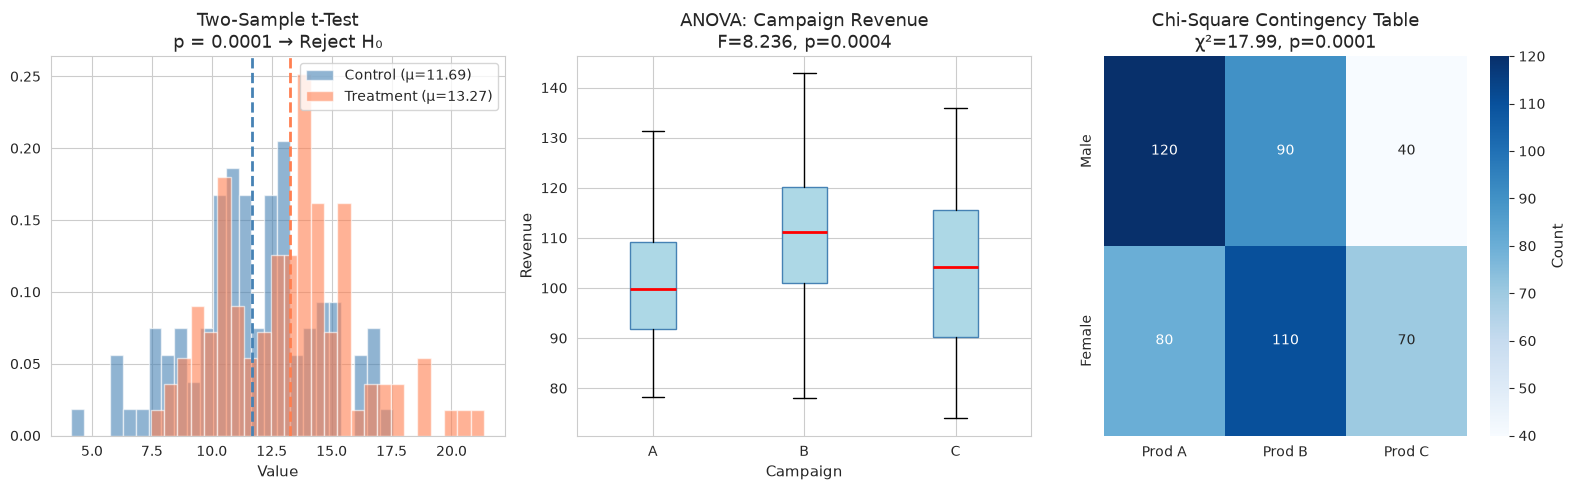

In [8]:
# ── Visualizing t-test and ANOVA ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# t-test visualization
np.random.seed(42)
ctrl = np.random.normal(12.0, 3.0, 100)
trt  = np.random.normal(13.2, 3.0, 100)

axes[0].hist(ctrl, bins=25, alpha=0.6, color='steelblue', label=f'Control (μ={np.mean(ctrl):.2f})', density=True)
axes[0].hist(trt,  bins=25, alpha=0.6, color='coral',     label=f'Treatment (μ={np.mean(trt):.2f})', density=True)
axes[0].axvline(np.mean(ctrl), color='steelblue', lw=2, linestyle='--')
axes[0].axvline(np.mean(trt),  color='coral',     lw=2, linestyle='--')
_, p = ttest_ind(ctrl, trt)
axes[0].set_title(f'Two-Sample t-Test\np = {p:.4f} → {"Reject H₀" if p<0.05 else "Fail to reject"}')
axes[0].legend(); axes[0].set_xlabel('Value')

# ANOVA boxplot
anova_data = pd.DataFrame({
    'Revenue': np.concatenate([campaign_a, campaign_b, campaign_c]),
    'Campaign': ['A']*50 + ['B']*50 + ['C']*50
})
axes[1].boxplot([campaign_a, campaign_b, campaign_c], tick_labels=['A', 'B', 'C'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'),
                medianprops=dict(color='red', lw=2))
axes[1].set_title(f'ANOVA: Campaign Revenue\nF={f_stat:.3f}, p={p_val:.4f}')
axes[1].set_xlabel('Campaign'); axes[1].set_ylabel('Revenue')

# Chi-square: mosaic-style heatmap
contingency = pd.DataFrame(observed, index=['Male','Female'], columns=['Prod A','Prod B','Prod C'])
sns.heatmap(contingency, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            cbar_kws={'label': 'Count'})
axes[2].set_title(f'Chi-Square Contingency Table\nχ²={chi2:.2f}, p={p:.4f}')

plt.tight_layout()
plt.show()

### INTERVIEW QUESTION 5
**Q: When do you use ANOVA instead of multiple t-tests? What is the multiple comparisons problem?**

**A:**
**Use ANOVA** when comparing 3+ groups. If you run 3 t-tests (A vs B, A vs C, B vs C), each at α=0.05:

$$P(\text{at least one false positive}) = 1 - (1-0.05)^3 = 0.143$$

With 10 groups (45 pairwise comparisons): $1 - 0.95^{45} \approx 0.90$ — nearly guaranteed false positive!

**ANOVA tests all groups simultaneously**, keeping Type I error at α.

**After significant ANOVA, use post-hoc tests:**
- **Tukey's HSD** — all pairwise comparisons, controls FWER
- **Bonferroni** — divide α by number of tests (conservative)
- **Dunnett's** — compare all groups to one control

**One-tailed vs Two-tailed:**
- Use **two-tailed** when you don't have a prior direction (almost always)
- Use **one-tailed** only with strong prior directional hypothesis (and pre-register it!)

---
## 6. Confidence Intervals

**Formula (for population mean, σ known):**
$$\bar{x} \pm z_{\alpha/2} \cdot \frac{\sigma}{\sqrt{n}}$$

**For unknown σ (use t-distribution):**
$$\bar{x} \pm t_{\alpha/2, n-1} \cdot \frac{s}{\sqrt{n}}$$

### The Most Common Wrong Interpretation

❌ **WRONG:** "There is a 95% probability that μ lies in this interval"
✓ **CORRECT:** "If we repeated this procedure many times, 95% of the constructed intervals would contain the true μ"

The true μ is fixed (not random) — the interval is random!

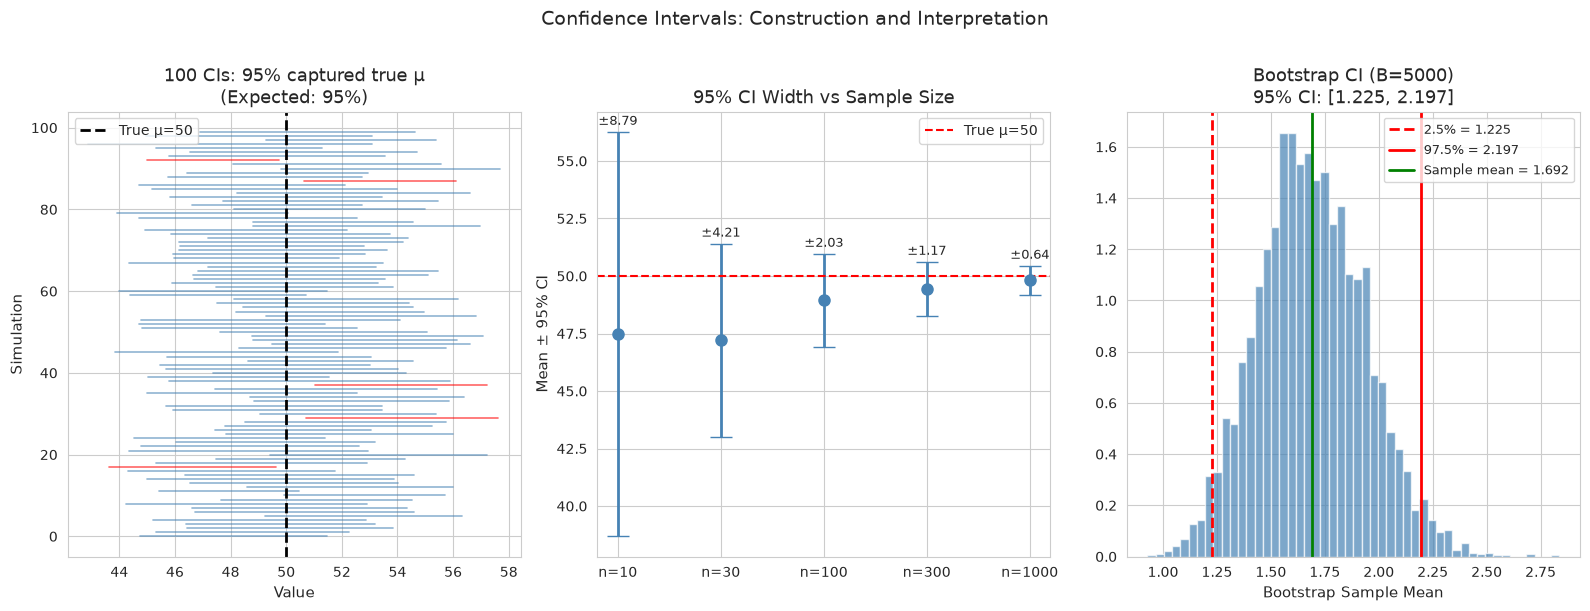

Bootstrap 95% CI for mean: [1.2251, 2.1968]
True mean (Exponential scale=2): 2.0
Sample mean: 1.6919


In [9]:
# ── Confidence Intervals ──
np.random.seed(42)
true_mu = 50
true_sigma = 10
n = 30
n_simulations = 100
alpha = 0.05

# Simulate many CIs and show which ones capture true mean
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

captured = 0
for i in range(n_simulations):
    sample = np.random.normal(true_mu, true_sigma, n)
    x_bar = np.mean(sample)
    se = np.std(sample, ddof=1) / np.sqrt(n)
    t_crit = t_dist.ppf(1 - alpha/2, df=n-1)
    lo, hi = x_bar - t_crit * se, x_bar + t_crit * se
    contains = lo <= true_mu <= hi
    captured += contains
    color = 'steelblue' if contains else 'red'
    axes[0].plot([lo, hi], [i, i], color=color, alpha=0.6, lw=1.2)

axes[0].axvline(true_mu, color='black', lw=2, linestyle='--', label=f'True μ={true_mu}')
axes[0].set_title(f'100 CIs: {captured}% captured true μ\n(Expected: 95%)')
axes[0].set_xlabel('Value'); axes[0].set_ylabel('Simulation')
axes[0].legend()

# Effect of n on CI width
ns = [10, 30, 100, 300, 1000]
sample_data = np.random.normal(true_mu, true_sigma, 1000)
for i, n_ci in enumerate(ns):
    s = sample_data[:n_ci]
    x_bar = np.mean(s)
    se = np.std(s, ddof=1) / np.sqrt(n_ci)
    t_crit = t_dist.ppf(0.975, df=n_ci-1)
    lo, hi = x_bar - t_crit * se, x_bar + t_crit * se
    axes[1].errorbar(i, x_bar, yerr=t_crit*se, fmt='o', capsize=8,
                    color='steelblue', markersize=8, lw=2)
    axes[1].text(i, hi + 0.3, f'±{t_crit*se:.2f}', ha='center', fontsize=9)

axes[1].axhline(true_mu, color='red', linestyle='--', lw=1.5, label=f'True μ={true_mu}')
axes[1].set_xticks(range(len(ns))); axes[1].set_xticklabels([f'n={n}' for n in ns])
axes[1].set_title('95% CI Width vs Sample Size')
axes[1].set_ylabel('Mean ± 95% CI'); axes[1].legend()

# Bootstrap CI
np.random.seed(42)
sample = np.random.exponential(scale=2, size=50)   # skewed data
B = 5000
bootstrap_means = [np.mean(np.random.choice(sample, size=len(sample), replace=True)) for _ in range(B)]

# Percentile bootstrap CI
ci_lo, ci_hi = np.percentile(bootstrap_means, [2.5, 97.5])
axes[2].hist(bootstrap_means, bins=50, color='steelblue', alpha=0.7, density=True, edgecolor='white')
axes[2].axvline(ci_lo, color='red', lw=2, linestyle='--', label=f'2.5% = {ci_lo:.3f}')
axes[2].axvline(ci_hi, color='red', lw=2, linestyle='-',  label=f'97.5% = {ci_hi:.3f}')
axes[2].axvline(np.mean(sample), color='green', lw=2, label=f'Sample mean = {np.mean(sample):.3f}')
axes[2].set_title(f'Bootstrap CI (B={B})\n95% CI: [{ci_lo:.3f}, {ci_hi:.3f}]')
axes[2].legend(fontsize=9); axes[2].set_xlabel('Bootstrap Sample Mean')

plt.suptitle('Confidence Intervals: Construction and Interpretation', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"Bootstrap 95% CI for mean: [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"True mean (Exponential scale=2): {2.0}")
print(f"Sample mean: {np.mean(sample):.4f}")

### INTERVIEW QUESTION 6
**Q: Explain confidence intervals. What's the difference between a 95% CI and a 99% CI?**

**A:**
A **95% CI** is a range constructed such that if you repeated your sampling procedure many times, 95% of the resulting intervals would contain the true parameter.

**Key properties:**
- **Wider CI** = more confidence but less precision (99% CI is wider than 95%)
- **Larger n** = narrower CI (precision scales as 1/√n)
- **Higher variance** = wider CI

**Bootstrap CI advantages:**
- No distributional assumptions (parametric CI assumes normality)
- Works for any statistic (median, correlation, AUC, custom metric)
- Essential for complex models where analytical formulas don't exist

**Practical insight:** In DS, report CIs alongside point estimates. A CTR lift of +2% with CI [+0.1%, +3.9%] is very different from CI [+1.8%, +2.2%] even though both have p < 0.05.

---
## 7. Correlation vs Causation

### Three Correlation Coefficients

| Measure | Formula | Use When |
|---|---|---|
| **Pearson (r)** | $r = \frac{\sum(x_i-\bar{x})(y_i-\bar{y})}{(n-1)s_xs_y}$ | Linear relationship, continuous, normal |
| **Spearman (ρ)** | Pearson on ranks | Monotonic (non-linear), ordinal, outliers |
| **Kendall (τ)** | Concordant vs discordant pairs | Small n, many ties, robust |

**Pearson assumes:** linearity, no extreme outliers, roughly normal

**Spearman/Kendall:** non-parametric, rank-based, more robust

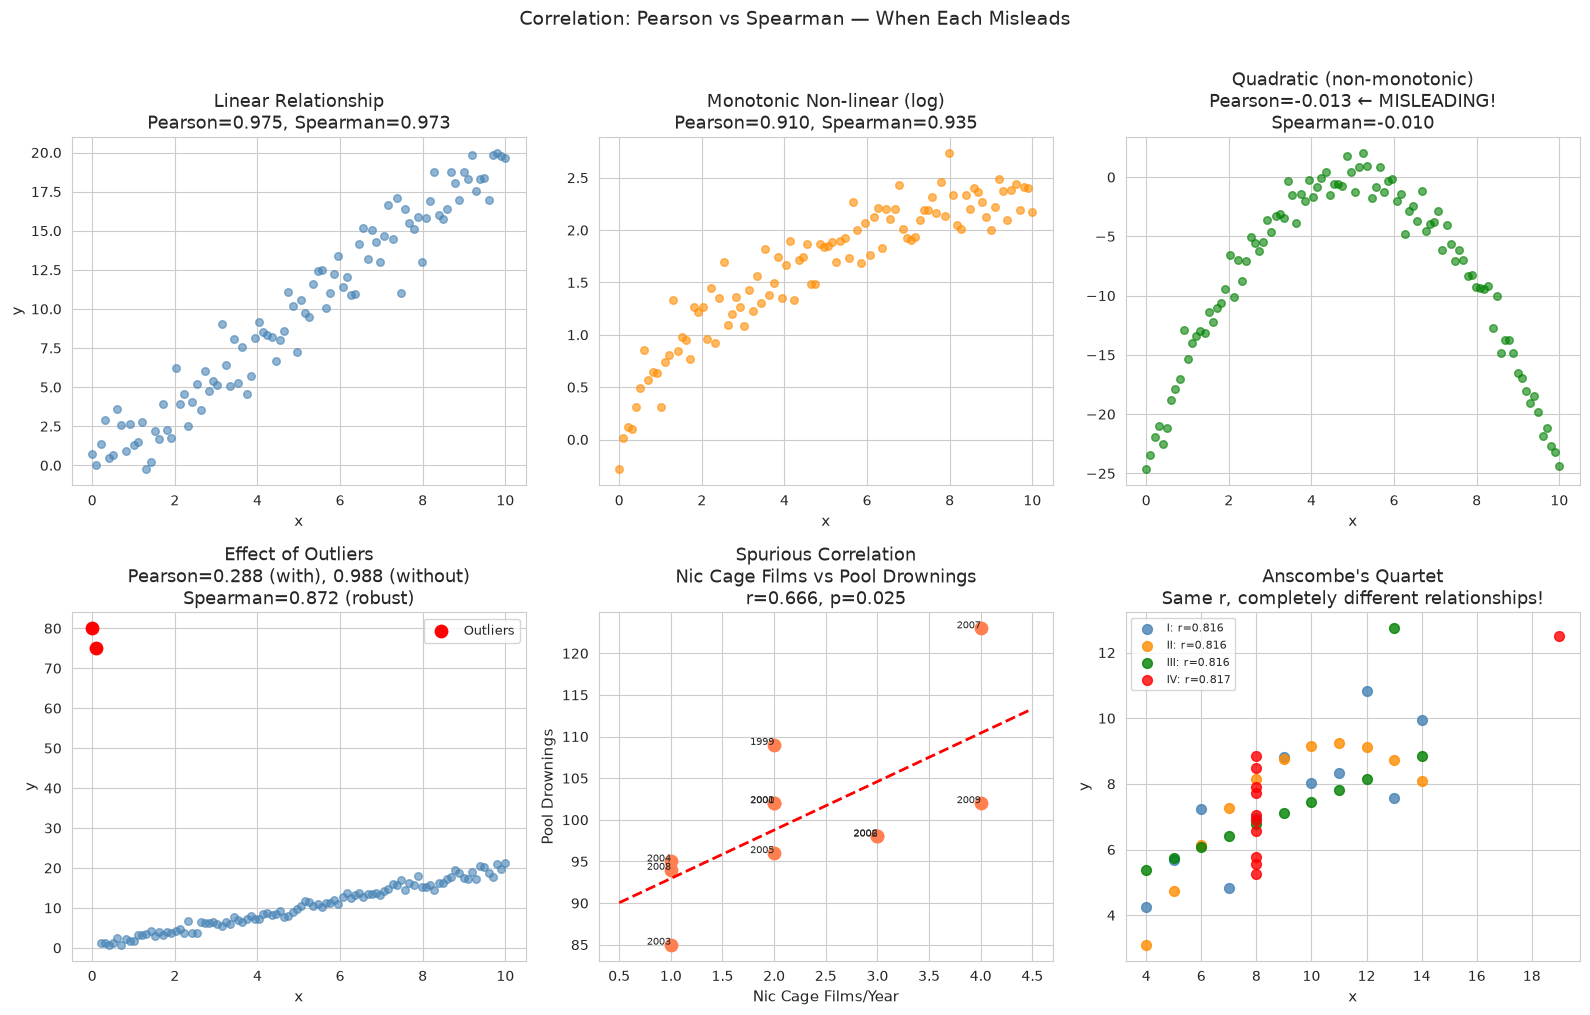

In [10]:
# ── Correlation: Pearson vs Spearman vs Kendall ──
np.random.seed(42)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Generate different relationship types
n = 100
x = np.linspace(0, 10, n)

# 1. Linear
y_linear = 2*x + np.random.normal(0, 1.5, n)
r_p, _ = pearsonr(x, y_linear)
r_s, _ = spearmanr(x, y_linear)
r_k, _ = kendalltau(x, y_linear)
axes[0,0].scatter(x, y_linear, alpha=0.6, color='steelblue', s=30)
axes[0,0].set_title(f'Linear Relationship\nPearson={r_p:.3f}, Spearman={r_s:.3f}')
axes[0,0].set_xlabel('x'); axes[0,0].set_ylabel('y')

# 2. Monotonic non-linear
y_mono = np.log(x + 1) + np.random.normal(0, 0.2, n)
r_p, _ = pearsonr(x, y_mono)
r_s, _ = spearmanr(x, y_mono)
axes[0,1].scatter(x, y_mono, alpha=0.6, color='darkorange', s=30)
axes[0,1].set_title(f'Monotonic Non-linear (log)\nPearson={r_p:.3f}, Spearman={r_s:.3f}')
axes[0,1].set_xlabel('x')

# 3. Non-linear (quadratic) — Pearson misses it
y_quad = -(x-5)**2 + np.random.normal(0, 1, n)
r_p, _ = pearsonr(x, y_quad)
r_s, _ = spearmanr(x, y_quad)
axes[0,2].scatter(x, y_quad, alpha=0.6, color='green', s=30)
axes[0,2].set_title(f'Quadratic (non-monotonic)\nPearson={r_p:.3f} ← MISLEADING!\nSpearman={r_s:.3f}')
axes[0,2].set_xlabel('x')

# 4. With outliers
y_out = 2*x + np.random.normal(0, 1, n)
y_out[0], y_out[1] = 80, 75   # two extreme outliers
r_p_with, _ = pearsonr(x, y_out)
r_s_with, _ = spearmanr(x, y_out)
r_p_wo, _ = pearsonr(x[2:], y_out[2:])
axes[1,0].scatter(x, y_out, alpha=0.6, color='steelblue', s=30)
axes[1,0].scatter(x[:2], y_out[:2], color='red', s=80, zorder=5, label='Outliers')
axes[1,0].set_title(f'Effect of Outliers\nPearson={r_p_with:.3f} (with), {r_p_wo:.3f} (without)\nSpearman={r_s_with:.3f} (robust)')
axes[1,0].legend(fontsize=9); axes[1,0].set_xlabel('x'); axes[1,0].set_ylabel('y')

# 5. Spurious correlation example
# Nicolas Cage films per year vs pool drownings (classic spurious correlation)
years = np.arange(1999, 2010)
cage_films = np.array([2, 2, 2, 3, 1, 1, 2, 3, 4, 1, 4])
pool_drownings = np.array([109, 102, 102, 98, 85, 95, 96, 98, 123, 94, 102])
r_p, p_val = pearsonr(cage_films, pool_drownings)
axes[1,1].scatter(cage_films, pool_drownings, color='coral', s=80)
for i, yr in enumerate(years):
    axes[1,1].annotate(str(yr), (cage_films[i], pool_drownings[i]), fontsize=7, ha='right')
m, b = np.polyfit(cage_films, pool_drownings, 1)
xfit = np.linspace(0.5, 4.5, 50)
axes[1,1].plot(xfit, m*xfit + b, 'r--', lw=2)
axes[1,1].set_title(f'Spurious Correlation\nNic Cage Films vs Pool Drownings\nr={r_p:.3f}, p={p_val:.3f}')
axes[1,1].set_xlabel('Nic Cage Films/Year'); axes[1,1].set_ylabel('Pool Drownings')

# 6. Anscombe's Quartet
anscombe = {
    'I':   ([10,8,13,9,11,14,6,4,12,7,5], [8.04,6.95,7.58,8.81,8.33,9.96,7.24,4.26,10.84,4.82,5.68]),
    'II':  ([10,8,13,9,11,14,6,4,12,7,5], [9.14,8.14,8.74,8.77,9.26,8.10,6.13,3.10,9.13,7.26,4.74]),
    'III': ([10,8,13,9,11,14,6,4,12,7,5], [7.46,6.77,12.74,7.11,7.81,8.84,6.08,5.39,8.15,6.42,5.73]),
    'IV':  ([8,8,8,8,8,8,8,8,8,8,19], [6.58,5.76,7.71,8.84,8.47,7.04,5.25,5.56,7.91,6.89,12.50]),
}
colors_a = ['steelblue', 'darkorange', 'green', 'red']
for (name, (ax, ay)), color in zip(anscombe.items(), colors_a):
    axes[1,2].scatter(ax, ay, label=f'{name}: r={pearsonr(ax,ay)[0]:.3f}', color=color, s=50, alpha=0.8)
axes[1,2].set_title("Anscombe's Quartet\nSame r, completely different relationships!")
axes[1,2].legend(fontsize=8); axes[1,2].set_xlabel('x'); axes[1,2].set_ylabel('y')

plt.suptitle('Correlation: Pearson vs Spearman — When Each Misleads', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### INTERVIEW QUESTION 7
**Q: Correlation vs causation — give an example. When would you use Spearman over Pearson?**

**A:**

**Correlation ≠ Causation** — classic examples:
- Ice cream sales correlate with drownings (both caused by summer heat — **confounding**)
- Shoe size correlates with reading ability in children (both caused by age — **lurking variable**)
- Nic Cage films per year correlates with pool drownings — pure **spurious correlation**

**Establishing causation requires:**
- Randomized controlled experiment (gold standard)
- Or: instrumental variables, difference-in-differences, regression discontinuity, propensity score matching

**Spearman > Pearson when:**
1. Relationship is monotonic but non-linear (e.g., log relationship)
2. Data has outliers (Pearson is outlier-sensitive)
3. Variables are ordinal (satisfaction ratings, star ratings)
4. You can't assume bivariate normality

**Kendall's τ** is preferred for small samples and when many tied ranks exist (common in ordinal survey data).

---
## 8. Bayes' Theorem

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)} = \frac{P(B|A) \cdot P(A)}{P(B|A)P(A) + P(B|\neg A)P(\neg A)}$$

| Term | Name | Meaning |
|---|---|---|
| $P(A)$ | Prior | Belief before seeing evidence |
| $P(B\|A)$ | Likelihood | How probable is the evidence given A? |
| $P(A\|B)$ | Posterior | Updated belief after evidence |
| $P(B)$ | Marginal (normalizer) | Total probability of evidence |

MEDICAL TEST EXAMPLE (Base Rate Neglect Trap)
Disease prevalence:  0.1%
Test sensitivity:    99%
Test specificity:    99%

You test POSITIVE. What is P(disease | positive)?

Intuitive (WRONG) answer: ~99%
Bayesian answer:           9.0%  ← HUGE DIFFERENCE!

Reasoning: For every 10,000 people tested:
  True positives:  9 (sick, correctly flagged)
  False positives: 99 (healthy, wrongly flagged)
  PPV = 9 / (9 + 99) = 0.090

NAIVE BAYES CONNECTION


Gaussian Naive Bayes accuracy: 0.9300
Naive Bayes applies Bayes' theorem assuming feature independence:
P(class|features) ∝ P(class) × ∏P(feature_i|class)


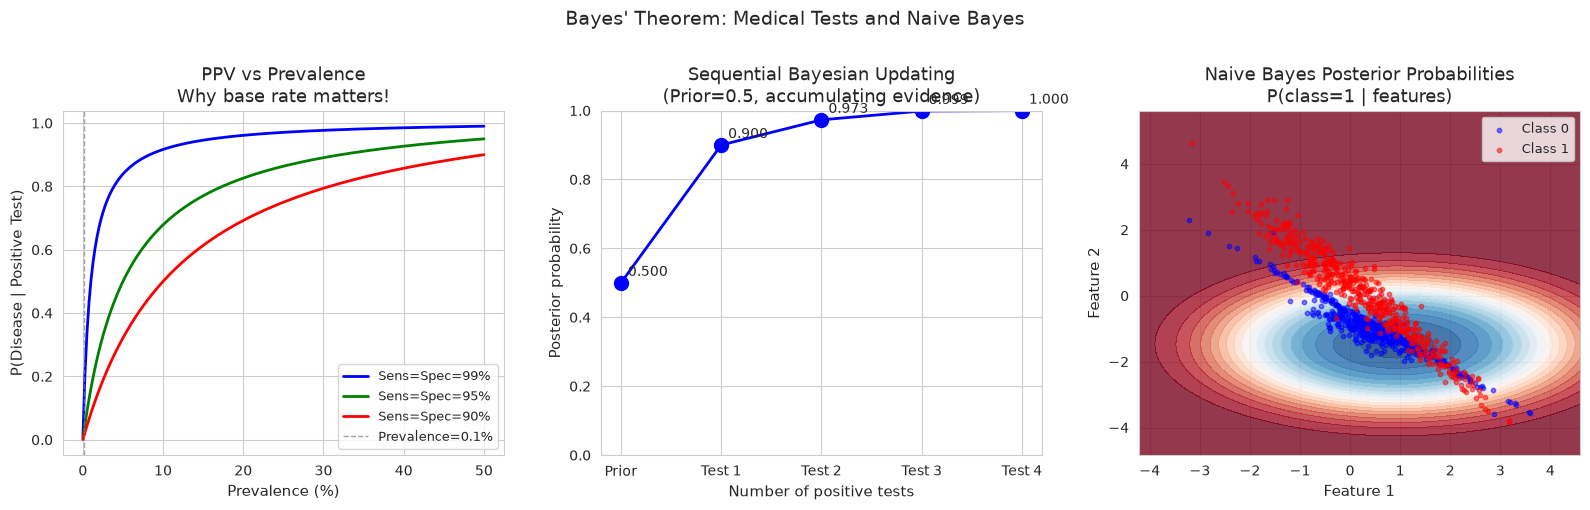

In [11]:
# ── Bayes' Theorem: Medical Test Example ──
def bayes_medical_test(prevalence, sensitivity, specificity):
    """
    prevalence  = P(disease)
    sensitivity = P(positive | disease)     = true positive rate
    specificity = P(negative | no disease)  = true negative rate
    Returns P(disease | positive test)
    """
    P_disease   = prevalence
    P_no_disease = 1 - prevalence
    P_pos_given_disease    = sensitivity          # TP rate
    P_pos_given_no_disease = 1 - specificity      # FP rate

    # Bayes formula
    numerator   = P_pos_given_disease * P_disease
    denominator = (P_pos_given_disease * P_disease +
                   P_pos_given_no_disease * P_no_disease)
    posterior = numerator / denominator
    return posterior

# Classic example: rare disease
print("=" * 60)
print("MEDICAL TEST EXAMPLE (Base Rate Neglect Trap)")
print("=" * 60)
prev   = 0.001   # 0.1% of population has disease
sens   = 0.99    # 99% sensitivity
spec   = 0.99    # 99% specificity

ppv = bayes_medical_test(prev, sens, spec)
print(f"Disease prevalence:  {prev*100:.1f}%")
print(f"Test sensitivity:    {sens*100:.0f}%")
print(f"Test specificity:    {spec*100:.0f}%")
print(f"\nYou test POSITIVE. What is P(disease | positive)?")
print(f"\nIntuitive (WRONG) answer: ~99%")
print(f"Bayesian answer:           {ppv*100:.1f}%  ← HUGE DIFFERENCE!")
print(f"\nReasoning: For every 10,000 people tested:")
print(f"  True positives:  {int(10000*prev*sens)} (sick, correctly flagged)")
print(f"  False positives: {int(10000*(1-prev)*(1-spec))} (healthy, wrongly flagged)")
print(f"  PPV = {int(10000*prev*sens)} / ({int(10000*prev*sens)} + {int(10000*(1-prev)*(1-spec))}) = {ppv:.3f}")

# Visualization: how prevalence affects PPV
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

prevalences = np.linspace(0.0001, 0.5, 200)
ppvs_99  = [bayes_medical_test(p, 0.99, 0.99) for p in prevalences]
ppvs_95  = [bayes_medical_test(p, 0.95, 0.95) for p in prevalences]
ppvs_90  = [bayes_medical_test(p, 0.90, 0.90) for p in prevalences]

axes[0].plot(prevalences*100, ppvs_99, 'b-', lw=2, label='Sens=Spec=99%')
axes[0].plot(prevalences*100, ppvs_95, 'g-', lw=2, label='Sens=Spec=95%')
axes[0].plot(prevalences*100, ppvs_90, 'r-', lw=2, label='Sens=Spec=90%')
axes[0].axvline(0.1, color='gray', linestyle='--', lw=1, alpha=0.7, label='Prevalence=0.1%')
axes[0].set_xlabel('Prevalence (%)'); axes[0].set_ylabel('P(Disease | Positive Test)')
axes[0].set_title('PPV vs Prevalence\nWhy base rate matters!')
axes[0].legend(fontsize=9)

# Bayesian updating
prior = 0.5
likelihoods = [0.9, 0.8, 0.95, 0.85]   # sequential test results (all positive)
posteriors = [prior]
current = prior
for lk in likelihoods:
    current = (lk * current) / (lk * current + (1-lk) * (1-current))
    posteriors.append(current)

axes[1].plot(range(len(posteriors)), posteriors, 'bo-', lw=2, markersize=10)
for i, p in enumerate(posteriors):
    axes[1].annotate(f'{p:.3f}', (i, p), textcoords='offset points', xytext=(5, 5), fontsize=10)
axes[1].set_title('Sequential Bayesian Updating\n(Prior=0.5, accumulating evidence)')
axes[1].set_xlabel('Number of positive tests'); axes[1].set_ylabel('Posterior probability')
axes[1].set_xticks(range(len(posteriors)))
axes[1].set_xticklabels(['Prior'] + [f'Test {i+1}' for i in range(len(likelihoods))])
axes[1].set_ylim(0, 1)

# Naive Bayes connection
print("\n" + "=" * 60)
print("NAIVE BAYES CONNECTION")
print("=" * 60)

# Simple spam classification
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X, y = make_classification(n_samples=1000, n_features=5, n_informative=3,
                           n_redundant=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
nb_clf = GaussianNB()
nb_clf.fit(X_train, y_train)
y_pred = nb_clf.predict(X_test)
acc = (y_pred == y_test).mean()
print(f"Gaussian Naive Bayes accuracy: {acc:.4f}")
print("Naive Bayes applies Bayes' theorem assuming feature independence:")
print("P(class|features) ∝ P(class) × ∏P(feature_i|class)")

# Posterior probability plot
X_2d = X[:, :2]
nb_2d = GaussianNB()
nb_2d.fit(X_2d, y)
xx, yy = np.meshgrid(np.linspace(X_2d[:,0].min()-1, X_2d[:,0].max()+1, 100),
                      np.linspace(X_2d[:,1].min()-1, X_2d[:,1].max()+1, 100))
Z = nb_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)
axes[2].contourf(xx, yy, Z, levels=20, cmap='RdBu_r', alpha=0.8)
axes[2].scatter(X_2d[y==0, 0], X_2d[y==0, 1], c='blue', s=10, alpha=0.5, label='Class 0')
axes[2].scatter(X_2d[y==1, 0], X_2d[y==1, 1], c='red',  s=10, alpha=0.5, label='Class 1')
axes[2].set_title('Naive Bayes Posterior Probabilities\nP(class=1 | features)')
axes[2].legend(fontsize=9)
axes[2].set_xlabel('Feature 1'); axes[2].set_ylabel('Feature 2')

plt.suptitle("Bayes' Theorem: Medical Tests and Naive Bayes", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### INTERVIEW QUESTION 8
**Q: A test for a disease has 99% sensitivity and 99% specificity. The disease affects 1 in 1000 people. You test positive. What is the probability you have the disease?**

**A:** Using Bayes' theorem:

$$P(D|+) = \frac{P(+|D) \cdot P(D)}{P(+|D)\cdot P(D) + P(+|\bar{D})\cdot P(\bar{D})}$$

$$= \frac{0.99 \times 0.001}{0.99 \times 0.001 + 0.01 \times 0.999} \approx \frac{0.00099}{0.01098} \approx 9\%$$

Despite a 99% accurate test, there's only a ~9% chance you're sick! This is **base rate neglect** — the disease is so rare that false positives (0.01 × 999 = ~10) swamp true positives (0.99 × 1 ≈ 1).

**ML connection:** In fraud detection (rare events), a 99% accurate classifier is useless if it just predicts "no fraud" always (since 99.5% of transactions are legitimate). Use precision/recall/F1, not accuracy.

---
## 9. Expected Value and Variance

### Key Formulas

**Expected Value (discrete):** $E[X] = \sum_x x \cdot P(X=x)$

**Expected Value (continuous):** $E[X] = \int_{-\infty}^{\infty} x f(x) dx$

**Variance:** $\text{Var}(X) = E[(X-\mu)^2] = E[X^2] - (E[X])^2$

### Linearity of Expectation
$$E[aX + bY] = aE[X] + bE[Y]$$  (always true, even if X, Y are dependent!)

### Variance of Sum
$$\text{Var}(X + Y) = \text{Var}(X) + \text{Var}(Y) + 2\text{Cov}(X,Y)$$
$$\text{Var}(X + Y) = \text{Var}(X) + \text{Var}(Y)$$  (only if X, Y are independent!)

### Covariance
$$\text{Cov}(X,Y) = E[(X-\mu_X)(Y-\mu_Y)] = E[XY] - E[X]E[Y]$$

1. EXPECTED VALUE - Linearity of Expectation
Fair die E[X] = 3.5031  (theoretical: 3.5000)
E[X+Y] = 7.0023  (theoretical: 7.0000)  linearity!
E[X + X] = 7.0062  (= 2*E[X] = 7.0062) works for dependent too!

2. VARIANCE - Sum of Random Variables
Var(X) = 3.9717  (theoretical: 4.000)
Var(Y) = 8.9754  (theoretical: 9.000)
Var(X+Y) = 12.9373  (theoretical: 13.000) -- X,Y independent

With correlation rho=0.7:
Cov(X,Y) = 8.3455
Var(X+Y) = 42.8392  (theoretical: 42.8394)

3. COVARIANCE MATRIX
Covariance matrix:
[[ 4.12  0.    8.67]
 [ 0.    8.97  0.27]
 [ 8.67  0.27 22.82]]

Correlation matrix:
[[1.    0.    0.894]
 [0.    1.    0.019]
 [0.894 0.019 1.   ]]


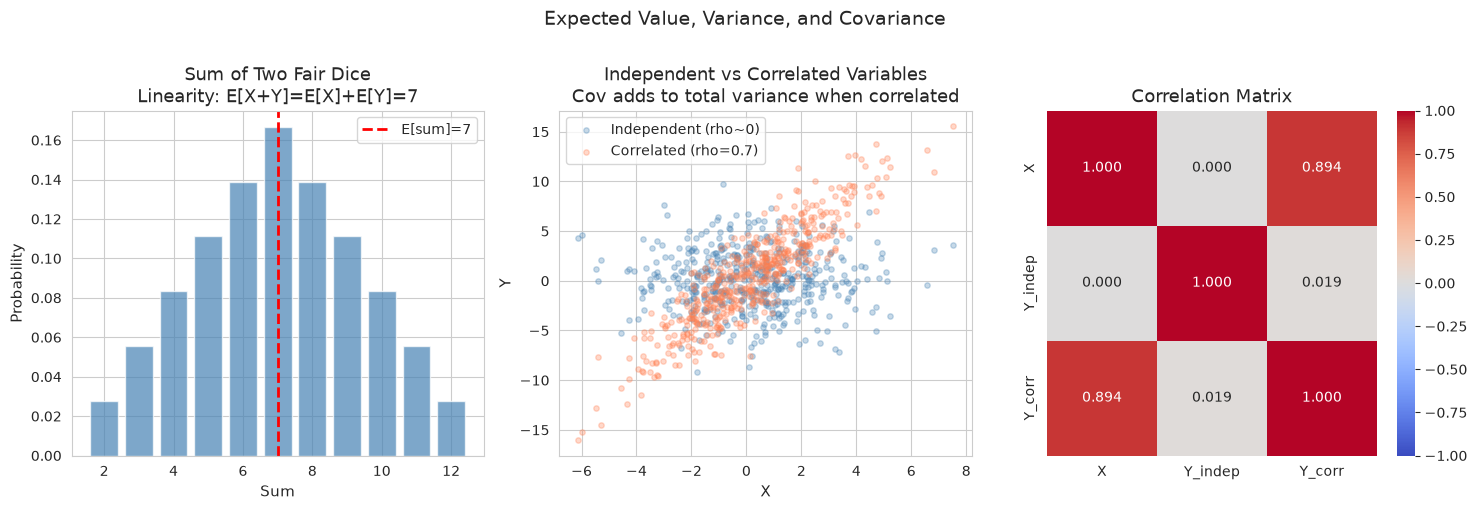

In [12]:
# Expected Value, Variance, and Covariance
np.random.seed(42)

print("=" * 55)
print("1. EXPECTED VALUE - Linearity of Expectation")
print("=" * 55)

n_rolls = 100_000
die = np.random.randint(1, 7, n_rolls)
print(f"Fair die E[X] = {np.mean(die):.4f}  (theoretical: {(1+2+3+4+5+6)/6:.4f})")

die2 = np.random.randint(1, 7, n_rolls)
print(f"E[X+Y] = {np.mean(die + die2):.4f}  (theoretical: {2*(1+6)/2:.4f})  linearity!")
print(f"E[X + X] = {np.mean(die + die):.4f}  (= 2*E[X] = {2*np.mean(die):.4f}) works for dependent too!")

print("\n" + "=" * 55)
print("2. VARIANCE - Sum of Random Variables")
print("=" * 55)

X = np.random.normal(0, 2, 100_000)
Y = np.random.normal(0, 3, 100_000)

print(f"Var(X) = {np.var(X):.4f}  (theoretical: 4.000)")
print(f"Var(Y) = {np.var(Y):.4f}  (theoretical: 9.000)")
print(f"Var(X+Y) = {np.var(X+Y):.4f}  (theoretical: 13.000) -- X,Y independent")

rho = 0.7
Y_corr = rho * X + np.sqrt(1 - rho**2) * np.random.normal(0, 1, 100_000)
Y_corr *= 3
cov_xy = np.cov(X, Y_corr)[0,1]
print(f"\nWith correlation rho={rho}:")
print(f"Cov(X,Y) = {cov_xy:.4f}")
print(f"Var(X+Y) = {np.var(X+Y_corr):.4f}  (theoretical: {np.var(X)+np.var(Y_corr)+2*cov_xy:.4f})")

print("\n" + "=" * 55)
print("3. COVARIANCE MATRIX")
print("=" * 55)
data = np.column_stack([X[:1000], Y[:1000], Y_corr[:1000]])
cov_matrix = np.cov(data.T)
corr_matrix = np.corrcoef(data.T)
print("Covariance matrix:")
print(np.round(cov_matrix, 2))
print("\nCorrelation matrix:")
print(np.round(corr_matrix, 3))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

outcomes = np.arange(2, 13)
probs = np.array([len([i+j for i in range(1,7) for j in range(1,7) if i+j==s]) for s in outcomes]) / 36
axes[0].bar(outcomes, probs, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].axvline(7, color='red', lw=2, linestyle='--', label='E[sum]=7')
axes[0].set_title('Sum of Two Fair Dice\nLinearity: E[X+Y]=E[X]+E[Y]=7')
axes[0].set_xlabel('Sum'); axes[0].set_ylabel('Probability')
axes[0].legend()

n_show = 500
axes[1].scatter(X[:n_show], Y[:n_show], alpha=0.3, s=15, color='steelblue', label='Independent (rho~0)')
axes[1].scatter(X[:n_show], Y_corr[:n_show], alpha=0.3, s=15, color='coral', label=f'Correlated (rho={rho})')
axes[1].set_title('Independent vs Correlated Variables\nCov adds to total variance when correlated')
axes[1].legend(); axes[1].set_xlabel('X'); axes[1].set_ylabel('Y')

labels = ['X', 'Y_indep', 'Y_corr']
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=axes[2],
            xticklabels=labels, yticklabels=labels)
axes[2].set_title('Correlation Matrix')

plt.suptitle('Expected Value, Variance, and Covariance', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### INTERVIEW QUESTION 9
**Q: What is the variance of the sum X+Y? Does it matter if they are correlated?**

**A:**

$$\text{Var}(X+Y) = \text{Var}(X) + \text{Var}(Y) + 2\text{Cov}(X,Y)$$

- **If independent:** $\text{Cov}(X,Y) = 0$, so $\text{Var}(X+Y) = \text{Var}(X) + \text{Var}(Y)$
- **If positively correlated:** variance of sum is **larger** than sum of variances
- **If negatively correlated:** variance of sum is **smaller** — this is why portfolio diversification works!

**Finance insight:** If two stocks are negatively correlated (ρ = -1), combining them gives near-zero portfolio variance.

**ML insight:** Ensemble methods (bagging) reduce variance by averaging independent models: $\text{Var}(\frac{1}{n}\sum X_i) = \frac{\sigma^2}{n}$. If models are correlated, the reduction is less — explains why diverse ensembles outperform homogeneous ones.

---
## 10. A/B Testing — Complete Framework

### Decision Framework

```
1. Define metric (conversion rate, revenue, retention)
2. Calculate required sample size (power analysis)  
3. Run experiment (randomly assign users)
4. Check statistical significance (p < alpha)
5. Check practical significance (effect > MDE)
6. Consider multiple testing corrections
7. Make business decision
```

### Sample Size Formula (two proportions):

$$n = \frac{(z_{\alpha/2} + z_\beta)^2 \cdot (p_1(1-p_1) + p_2(1-p_2))}{(p_1-p_2)^2}$$

Where $z_{\alpha/2} = 1.96$ for alpha=0.05 and $z_\beta = 0.84$ for 80% power.

A/B TEST DESIGN: Power Analysis
Baseline CTR: 5.0%
MDE: +0.5pp
Required n per group: 31,231
Total experiment size: 62,462 users

Control:   1560/31231 = 4.995%
Treatment: 1762/31231 = 5.642%
Absolute lift: +0.647pp
Relative lift: +12.95%
z-statistic: -3.6018, p-value: 0.0003
Decision: SHIP IT
95% CI for lift: [+0.295pp, +0.999pp]

MULTIPLE TESTING PROBLEM:
    1 tests: FWER=0.0500, Bonferroni alpha=0.05000
    5 tests: FWER=0.2262, Bonferroni alpha=0.01000
   10 tests: FWER=0.4013, Bonferroni alpha=0.00500
   20 tests: FWER=0.6415, Bonferroni alpha=0.00250
   50 tests: FWER=0.9231, Bonferroni alpha=0.00100



P-Hacking Simulation (n=5000):
  Test once (correct): FPR = 0.0478
  Peek 20 times (wrong): FPR = 0.2456


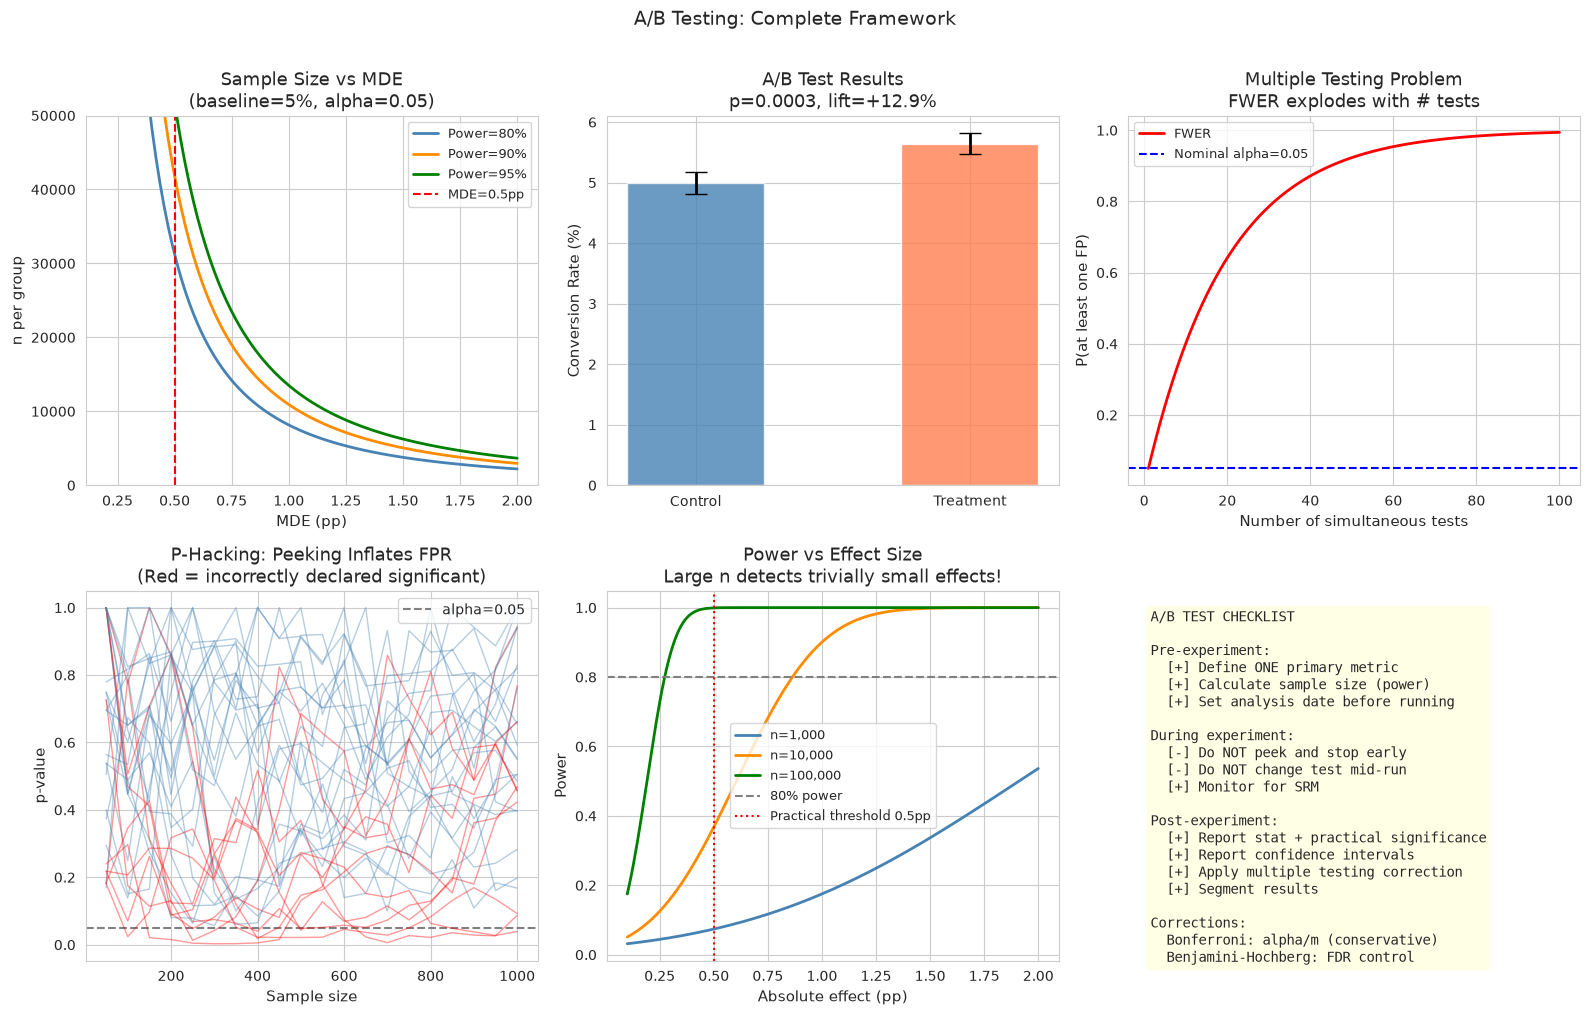

In [13]:
# A/B Testing: Complete Framework
from scipy.stats import norm as norm_dist

def sample_size_two_proportions(p1, p2, alpha=0.05, power=0.80):
    """Calculate required sample size per group for two-proportion z-test."""
    z_alpha = norm_dist.ppf(1 - alpha/2)
    z_beta  = norm_dist.ppf(power)
    n = ((z_alpha + z_beta)**2 * (p1*(1-p1) + p2*(1-p2))) / (p1 - p2)**2
    return int(np.ceil(n))

def two_proportion_ztest(n1, x1, n2, x2):
    """Two-proportion z-test for A/B testing."""
    p1, p2 = x1/n1, x2/n2
    p_pooled = (x1+x2) / (n1+n2)
    se = np.sqrt(p_pooled * (1-p_pooled) * (1/n1 + 1/n2))
    z = (p1 - p2) / se
    p_val = 2 * (1 - norm_dist.cdf(abs(z)))
    return z, p_val, p1, p2

# Step 1: Power Analysis
print("=" * 60)
print("A/B TEST DESIGN: Power Analysis")
print("=" * 60)
baseline_ctr = 0.05
mde = 0.005

required_n = sample_size_two_proportions(baseline_ctr, baseline_ctr + mde)
print(f"Baseline CTR: {baseline_ctr*100:.1f}%")
print(f"MDE: +{mde*100:.1f}pp")
print(f"Required n per group: {required_n:,}")
print(f"Total experiment size: {2*required_n:,} users")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

mdes = np.linspace(0.002, 0.02, 100)
for power, color in [(0.80, 'steelblue'), (0.90, 'darkorange'), (0.95, 'green')]:
    ns = [sample_size_two_proportions(0.05, 0.05+m, power=power) for m in mdes]
    axes[0,0].plot(mdes*100, ns, lw=2, color=color, label=f'Power={power*100:.0f}%')
axes[0,0].axvline(mde*100, color='red', linestyle='--', lw=1.5, label=f'MDE={mde*100:.1f}pp')
axes[0,0].set_title('Sample Size vs MDE\n(baseline=5%, alpha=0.05)')
axes[0,0].set_xlabel('MDE (pp)'); axes[0,0].set_ylabel('n per group')
axes[0,0].legend(fontsize=9); axes[0,0].set_ylim(0, 50000)

# Step 2: Simulate experiment
np.random.seed(42)
true_effect = 0.007
n_per_group = required_n

control_conv   = np.random.binomial(1, baseline_ctr, n_per_group)
treatment_conv = np.random.binomial(1, baseline_ctr + true_effect, n_per_group)

n1, x1 = n_per_group, control_conv.sum()
n2, x2 = n_per_group, treatment_conv.sum()
z, p_val, p_ctl, p_trt = two_proportion_ztest(n1, x1, n2, x2)

print(f"\nControl:   {x1}/{n1} = {p_ctl*100:.3f}%")
print(f"Treatment: {x2}/{n2} = {p_trt*100:.3f}%")
print(f"Absolute lift: {(p_trt-p_ctl)*100:+.3f}pp")
print(f"Relative lift: {(p_trt-p_ctl)/p_ctl*100:+.2f}%")
print(f"z-statistic: {z:.4f}, p-value: {p_val:.4f}")
decision = 'SHIP IT' if p_val < 0.05 else 'No significant difference'
print(f"Decision: {decision}")

se_diff = np.sqrt(p_ctl*(1-p_ctl)/n1 + p_trt*(1-p_trt)/n2)
ci_lo = (p_trt - p_ctl) - 1.96 * se_diff
ci_hi = (p_trt - p_ctl) + 1.96 * se_diff
print(f"95% CI for lift: [{ci_lo*100:+.3f}pp, {ci_hi*100:+.3f}pp]")

axes[0,1].bar(['Control', 'Treatment'], [p_ctl*100, p_trt*100],
              color=['steelblue', 'coral'], alpha=0.8, width=0.5, edgecolor='white')
axes[0,1].errorbar(['Control', 'Treatment'],
                   [p_ctl*100, p_trt*100],
                   yerr=[1.96*se_diff*100/2, 1.96*se_diff*100/2],
                   fmt='none', color='black', capsize=8, lw=2)
axes[0,1].set_title(f'A/B Test Results\np={p_val:.4f}, lift={((p_trt-p_ctl)/p_ctl*100):+.1f}%')
axes[0,1].set_ylabel('Conversion Rate (%)')

# Multiple testing problem
print(f"\nMULTIPLE TESTING PROBLEM:")
for k in [1, 5, 10, 20, 50]:
    fpr = 1 - (1-0.05)**k
    bonf = 0.05/k
    print(f"  {k:3d} tests: FWER={fpr:.4f}, Bonferroni alpha={bonf:.5f}")

tests = np.arange(1, 101)
fwer = 1 - (1-0.05)**tests
axes[0,2].plot(tests, fwer, 'r-', lw=2, label='FWER')
axes[0,2].axhline(0.05, color='blue', linestyle='--', lw=1.5, label='Nominal alpha=0.05')
axes[0,2].set_title('Multiple Testing Problem\nFWER explodes with # tests')
axes[0,2].set_xlabel('Number of simultaneous tests'); axes[0,2].set_ylabel('P(at least one FP)')
axes[0,2].legend(fontsize=9)

# P-hacking simulation
np.random.seed(0)
n_simulations = 5000
naive_fp = 0
peeking_fp = 0
for _ in range(n_simulations):
    data_c = np.random.binomial(1, 0.1, 1000)
    data_t = np.random.binomial(1, 0.1, 1000)
    _, p, _, _ = two_proportion_ztest(1000, data_c.sum(), 1000, data_t.sum())
    if p < 0.05: naive_fp += 1
    found_sig = False
    for i in range(50, 1001, 50):
        _, p_peek, _, _ = two_proportion_ztest(i, data_c[:i].sum(), i, data_t[:i].sum())
        if p_peek < 0.05:
            found_sig = True
            break
    if found_sig: peeking_fp += 1

print(f"\nP-Hacking Simulation (n={n_simulations}):")
print(f"  Test once (correct): FPR = {naive_fp/n_simulations:.4f}")
print(f"  Peek 20 times (wrong): FPR = {peeking_fp/n_simulations:.4f}")

# Sequential p-value paths
axes[1,0].axhline(0.05, color='gray', linestyle='--', lw=1.5, label='alpha=0.05')
for trial in range(30):
    np.random.seed(trial)
    data_c = np.random.binomial(1, 0.1, 1000)
    data_t = np.random.binomial(1, 0.1, 1000)
    ps = []
    for i in range(50, 1001, 50):
        _, p, _, _ = two_proportion_ztest(i, data_c[:i].sum(), i, data_t[:i].sum())
        ps.append(p)
    color = 'red' if any(p < 0.05 for p in ps) else 'steelblue'
    axes[1,0].plot(range(50, 1001, 50), ps, alpha=0.4, lw=1, color=color)
axes[1,0].set_title('P-Hacking: Peeking Inflates FPR\n(Red = incorrectly declared significant)')
axes[1,0].set_xlabel('Sample size'); axes[1,0].set_ylabel('p-value')
axes[1,0].legend()

# Power vs effect size
effects = np.linspace(0.001, 0.02, 200)
for n_fixed, color, lbl in [(1000,'steelblue','n=1,000'), (10000,'darkorange','n=10,000'), (100000,'green','n=100,000')]:
    powers = []
    for e in effects:
        ncp = e / np.sqrt(0.05*0.95*2/n_fixed)
        powers.append(norm_dist.cdf(ncp - 1.96))
    axes[1,1].plot(effects*100, powers, lw=2, color=color, label=lbl)
axes[1,1].axhline(0.80, color='gray', linestyle='--', lw=1.5, label='80% power')
axes[1,1].axvline(0.5, color='red', linestyle=':', lw=1.5, label='Practical threshold 0.5pp')
axes[1,1].set_title('Power vs Effect Size\nLarge n detects trivially small effects!')
axes[1,1].set_xlabel('Absolute effect (pp)'); axes[1,1].set_ylabel('Power')
axes[1,1].legend(fontsize=9)

# A/B checklist as text
axes[1,2].axis('off')
checklist = (
    "A/B TEST CHECKLIST\n\n"
    "Pre-experiment:\n"
    "  [+] Define ONE primary metric\n"
    "  [+] Calculate sample size (power)\n"
    "  [+] Set analysis date before running\n\n"
    "During experiment:\n"
    "  [-] Do NOT peek and stop early\n"
    "  [-] Do NOT change test mid-run\n"
    "  [+] Monitor for SRM\n\n"
    "Post-experiment:\n"
    "  [+] Report stat + practical significance\n"
    "  [+] Report confidence intervals\n"
    "  [+] Apply multiple testing correction\n"
    "  [+] Segment results\n\n"
    "Corrections:\n"
    "  Bonferroni: alpha/m (conservative)\n"
    "  Benjamini-Hochberg: FDR control"
)
axes[1,2].text(0.05, 0.95, checklist, transform=axes[1,2].transAxes,
               verticalalignment='top', fontsize=10,
               fontfamily='monospace',
               bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('A/B Testing: Complete Framework', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### INTERVIEW QUESTION 10
**Q: You run an A/B test and get p=0.04. Can you ship the feature?**

**A: Not necessarily.** Here is what to check:

1. **Was the test pre-registered?** Hypothesis, metric, and sample size must be set beforehand
2. **Did you peek?** Stopping early when p crosses 0.05 inflates FPR to 30%+
3. **Is the effect practically significant?** A CTR lift of +0.01% with n=10M may be statistically significant but not worth engineering cost
4. **Is this one of many tests?** If you tested 20 variants, expect ~1 false positive — apply Bonferroni/BH correction
5. **Sample ratio mismatch?** Verify n_control ≈ n_treatment (the 50/50 split worked correctly)
6. **Is the effect consistent across segments?** Simpson's paradox can hide harm in subgroups

**Practical significance** = effect size > business threshold (your MDE). Always report the CI for lift, not just p-value.

---
## 11. Sampling Methods

| Method | How it Works | When to Use |
|---|---|---|
| **Simple Random** | Each unit equally likely | Homogeneous population |
| **Stratified** | Sample proportionally from subgroups | Heterogeneous population, imbalanced classes |
| **Systematic** | Every k-th unit from ordered list | Large ordered populations |
| **Cluster** | Randomly sample groups, then all in group | Geographically dispersed populations |
| **Convenience** | Whoever is available | Quick/exploratory only (high bias risk) |

### Why Stratified Sampling Matters for ML
- Ensures minority classes are represented in train/test splits
- Critical for imbalanced classification (fraud, rare disease)
- `sklearn.model_selection.train_test_split(..., stratify=y)` is the standard approach

SAMPLING METHOD COMPARISON
Population fraud rate:        2.00%  (n=10000)
Simple random fraud rate:     1.80%  (n=500)
Stratified sampling rate:     2.00%  (n=500)
Systematic sampling rate:     1.60%  (n=500)



Over 1000 simulations (n=500):
  Simple random  - mean=1.96%, std=0.613%
  Stratified     - mean=2.00%, std=0.000%  (much lower variance!)


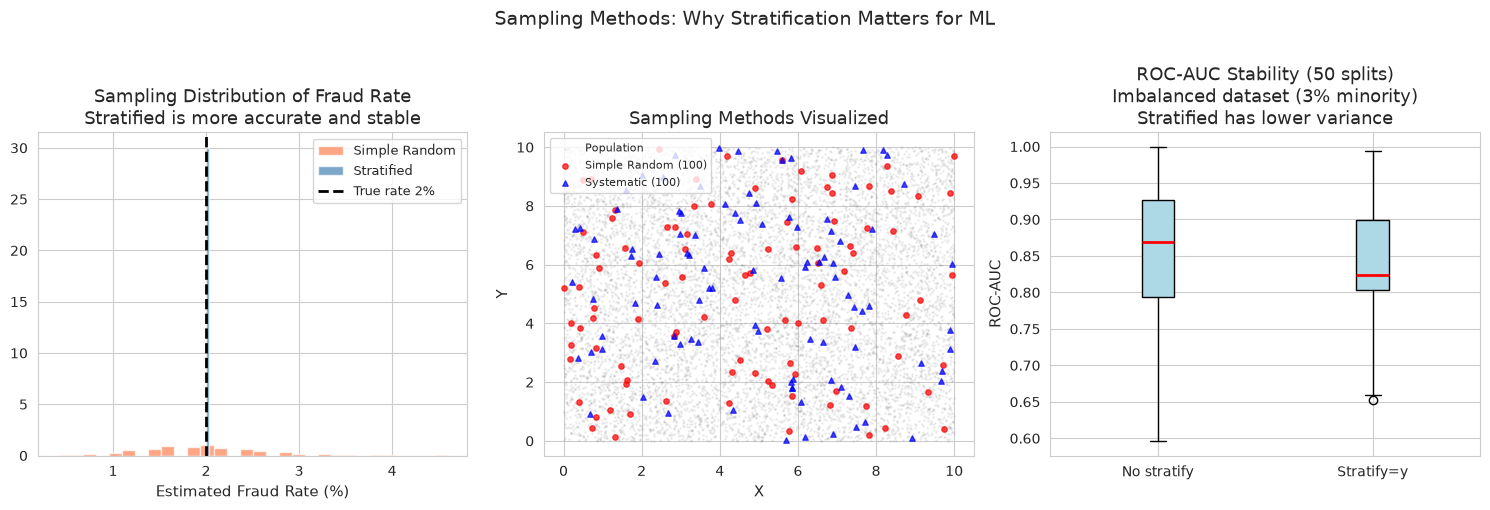

In [14]:
# Sampling Methods Comparison
np.random.seed(42)

# Create a population with class imbalance (fraud detection scenario)
N = 10000
fraud_rate = 0.02   # 2% fraud
labels = np.array([1]*int(N*fraud_rate) + [0]*int(N*(1-fraud_rate)))
np.random.shuffle(labels)

feature = np.where(labels==1,
                   np.random.normal(5, 1, N),   # fraud: higher amounts
                   np.random.normal(3, 1, N))    # normal: lower amounts

population = pd.DataFrame({'amount': feature, 'fraud': labels})

n_sample = 500

# 1. Simple random sampling
simple_sample = population.sample(n=n_sample, random_state=42)

# 2. Stratified sampling
from sklearn.model_selection import train_test_split
_, strat_sample = train_test_split(population, test_size=n_sample/N,
                                   stratify=population['fraud'], random_state=42)

# 3. Systematic sampling
step = N // n_sample
start = np.random.randint(0, step)
systematic_idx = np.arange(start, N, step)[:n_sample]
systematic_sample = population.iloc[systematic_idx]

# 4. Compare fraud rates
print("=" * 55)
print("SAMPLING METHOD COMPARISON")
print("=" * 55)
print(f"Population fraud rate:        {population['fraud'].mean()*100:.2f}%  (n={N})")
print(f"Simple random fraud rate:     {simple_sample['fraud'].mean()*100:.2f}%  (n={n_sample})")
print(f"Stratified sampling rate:     {strat_sample['fraud'].mean()*100:.2f}%  (n={n_sample})")
print(f"Systematic sampling rate:     {systematic_sample['fraud'].mean()*100:.2f}%  (n={n_sample})")
print()

# Show instability of simple random with rare class
n_simulations = 1000
simple_rates = [population.sample(n=n_sample, random_state=i)['fraud'].mean()
                for i in range(n_simulations)]
strat_rates  = []
for i in range(n_simulations):
    _, s = train_test_split(population, test_size=n_sample/N,
                            stratify=population['fraud'], random_state=i)
    strat_rates.append(s['fraud'].mean())

print(f"Over {n_simulations} simulations (n={n_sample}):")
print(f"  Simple random  - mean={np.mean(simple_rates)*100:.2f}%, std={np.std(simple_rates)*100:.3f}%")
print(f"  Stratified     - mean={np.mean(strat_rates)*100:.2f}%, std={np.std(strat_rates)*100:.3f}%  (much lower variance!)")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Sampling distributions
axes[0].hist(np.array(simple_rates)*100, bins=30, color='coral', alpha=0.7,
             density=True, label='Simple Random', edgecolor='white')
axes[0].hist(np.array(strat_rates)*100, bins=30, color='steelblue', alpha=0.7,
             density=True, label='Stratified', edgecolor='white')
axes[0].axvline(fraud_rate*100, color='black', lw=2, linestyle='--', label='True rate 2%')
axes[0].set_title('Sampling Distribution of Fraud Rate\nStratified is more accurate and stable')
axes[0].legend(fontsize=9); axes[0].set_xlabel('Estimated Fraud Rate (%)')

# Illustrate all 4 sampling methods visually
pop_x = np.random.uniform(0, 10, N)
pop_y = np.random.uniform(0, 10, N)
axes[1].scatter(pop_x, pop_y, s=1, alpha=0.1, color='gray', label='Population')
# Simple random
sr_idx = np.random.choice(N, 100, replace=False)
axes[1].scatter(pop_x[sr_idx], pop_y[sr_idx], s=15, color='red', alpha=0.7, label='Simple Random (100)')
# Systematic (grid-like)
sys_idx = np.arange(0, N, N//100)[:100]
axes[1].scatter(pop_x[sys_idx], pop_y[sys_idx], s=15, color='blue', alpha=0.7,
                marker='^', label='Systematic (100)')
axes[1].set_title('Sampling Methods Visualized')
axes[1].legend(fontsize=8); axes[1].set_xlabel('X'); axes[1].set_ylabel('Y')

# Train/test split with and without stratification
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

X_imb, y_imb = make_classification(n_samples=1000, n_features=10,
                                     weights=[0.97, 0.03], random_state=42)

aucs_no_strat, aucs_strat = [], []
for seed in range(50):
    # Without stratify
    X_tr, X_te, y_tr, y_te = train_test_split(X_imb, y_imb, test_size=0.2, random_state=seed)
    if len(np.unique(y_te)) > 1:
        rf = RandomForestClassifier(n_estimators=20, random_state=42)
        rf.fit(X_tr, y_tr)
        aucs_no_strat.append(roc_auc_score(y_te, rf.predict_proba(X_te)[:,1]))

    # With stratify
    X_tr, X_te, y_tr, y_te = train_test_split(X_imb, y_imb, test_size=0.2,
                                               stratify=y_imb, random_state=seed)
    rf2 = RandomForestClassifier(n_estimators=20, random_state=42)
    rf2.fit(X_tr, y_tr)
    aucs_strat.append(roc_auc_score(y_te, rf2.predict_proba(X_te)[:,1]))

axes[2].boxplot([aucs_no_strat, aucs_strat], tick_labels=['No stratify', 'Stratify=y'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', lw=2))
axes[2].set_title(f'ROC-AUC Stability (50 splits)\nImbalanced dataset (3% minority)\nStratified has lower variance')
axes[2].set_ylabel('ROC-AUC')

plt.suptitle('Sampling Methods: Why Stratification Matters for ML', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### INTERVIEW QUESTION 11
**Q: What is stratified sampling and when do you use it in ML?**

**A:**
Stratified sampling ensures each subgroup (stratum) appears in the sample in proportion to its presence in the population.

**When to use in ML:**
1. **Imbalanced classification** — if 2% of data is fraud, a random 80/20 split might put 0 or all frauds in the test set. `stratify=y` guarantees ~2% fraud in both train and test
2. **Cross-validation on imbalanced data** — use `StratifiedKFold` instead of `KFold`
3. **Small datasets** — random sampling variance is high; stratification reduces it

**Code pattern:**
```python
from sklearn.model_selection import train_test_split, StratifiedKFold
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2)
cv = StratifiedKFold(n_splits=5, shuffle=True)
```

**Bootstrap sampling** (sampling with replacement) is used in:
- Bagging/Random Forests (each tree trained on bootstrap sample)
- Bootstrap confidence intervals
- Estimating model variance

---
## 12. Common Interview Traps

These are the concepts most likely to trip you up in interviews:

1. **P-value misinterpretation** (covered in Section 4)
2. **Base rate neglect** (covered in Section 8)
3. **Simpson's Paradox** — aggregate trend reverses in subgroups
4. **Berkson's Paradox** — selection bias creates spurious correlations
5. **Survivorship Bias** — analyzing only survivors distorts conclusions
6. **Regression to the Mean** — extreme observations tend toward average on retest

SIMPSON'S PARADOX
MILD DISEASE:
  Treated: 81/90 = 90.0% recovery
  Control: 234/270 = 86.7% recovery
  Treatment BETTER by 3.3pp

SEVERE DISEASE:
  Treated: 105/210 = 50.0% recovery
  Control: 12/30 = 40.0% recovery
  Treatment BETTER by 10.0pp

AGGREGATE (Simpson's Paradox):
  Treated: 186/300 = 62.0% recovery
  Control: 246/300 = 82.0% recovery
  Treatment WORSE by -20.0pp  <- PARADOX!
  Reason: Treated group had MORE severe cases (confounding variable)

BERKSON'S PARADOX
Example: Hospital patients — intelligence and attractiveness appear negatively correlated
         in hospital patients, but not in general population.
Reason:  Being hospitalized requires EITHER low intelligence OR unattractive.
         Selection into the sample (hospital admission) creates artificial correlation.

REGRESSION TO THE MEAN
Example: Students who score worst on Test 1 tend to improve on Test 2
         NOT because of any intervention, but due to random chance!


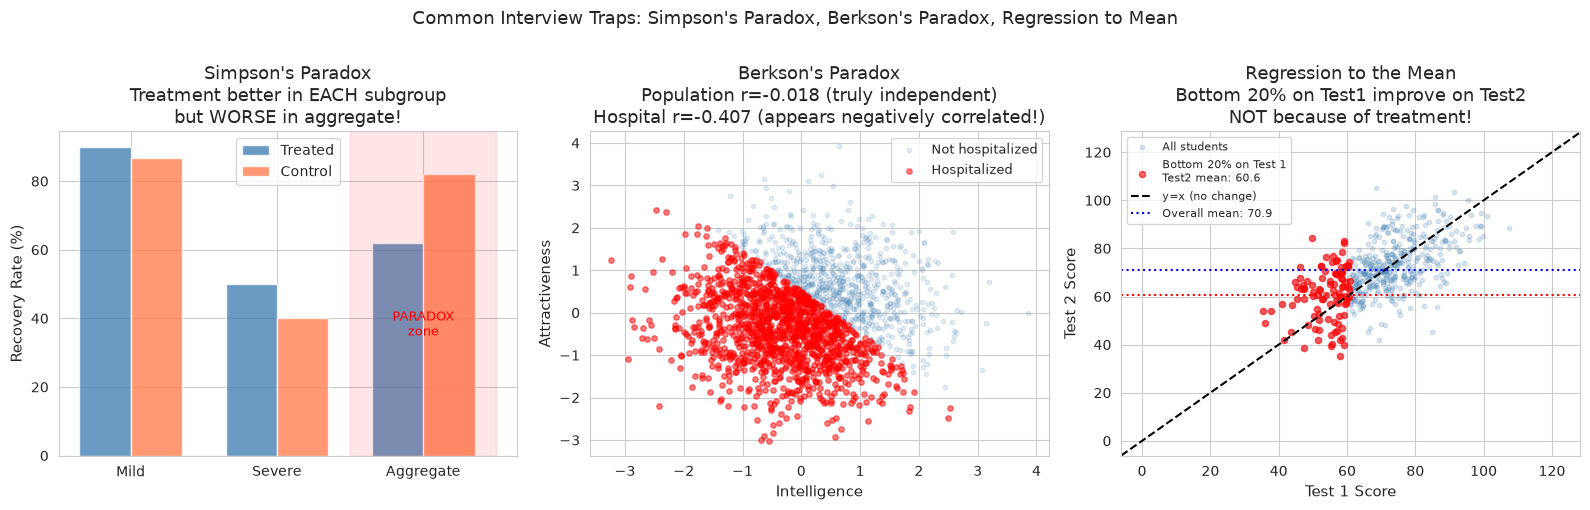

In [15]:
# Simpson's Paradox
print("=" * 60)
print("SIMPSON'S PARADOX")
print("=" * 60)

# Classic example: Treatment vs Control, but confounded by disease severity
# Mild disease patients
mild_treated  = {'treated': 90,  'recovered': 81}   # 90% recovery
mild_control  = {'treated': 270, 'recovered': 234}  # 86.7% recovery

# Severe disease patients  
severe_treated = {'treated': 210, 'recovered': 105}  # 50% recovery
severe_control = {'treated': 30,  'recovered': 12}   # 40% recovery

# Aggregate (combining both groups)
agg_treated = mild_treated['recovered'] + severe_treated['recovered']
agg_treated_n = mild_treated['treated'] + severe_treated['treated']
agg_control = mild_control['recovered'] + severe_control['recovered']
agg_control_n = mild_control['treated'] + severe_control['treated']

print("MILD DISEASE:")
print(f"  Treated: {mild_treated['recovered']}/{mild_treated['treated']} = {mild_treated['recovered']/mild_treated['treated']*100:.1f}% recovery")
print(f"  Control: {mild_control['recovered']}/{mild_control['treated']} = {mild_control['recovered']/mild_control['treated']*100:.1f}% recovery")
print(f"  Treatment BETTER by {(mild_treated['recovered']/mild_treated['treated'] - mild_control['recovered']/mild_control['treated'])*100:.1f}pp")

print("\nSEVERE DISEASE:")
print(f"  Treated: {severe_treated['recovered']}/{severe_treated['treated']} = {severe_treated['recovered']/severe_treated['treated']*100:.1f}% recovery")
print(f"  Control: {severe_control['recovered']}/{severe_control['treated']} = {severe_control['recovered']/severe_control['treated']*100:.1f}% recovery")
print(f"  Treatment BETTER by {(severe_treated['recovered']/severe_treated['treated'] - severe_control['recovered']/severe_control['treated'])*100:.1f}pp")

print("\nAGGREGATE (Simpson's Paradox):")
print(f"  Treated: {agg_treated}/{agg_treated_n} = {agg_treated/agg_treated_n*100:.1f}% recovery")
print(f"  Control: {agg_control}/{agg_control_n} = {agg_control/agg_control_n*100:.1f}% recovery")
print(f"  Treatment WORSE by {(agg_treated/agg_treated_n - agg_control/agg_control_n)*100:.1f}pp  <- PARADOX!")
print("  Reason: Treated group had MORE severe cases (confounding variable)")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Simpson's paradox visualization
categories = ['Mild', 'Severe', 'Aggregate']
treated_rates = [81/90, 105/210, agg_treated/agg_treated_n]
control_rates  = [234/270, 12/30, agg_control/agg_control_n]

x = np.arange(3)
w = 0.35
bars1 = axes[0].bar(x - w/2, [r*100 for r in treated_rates], w, label='Treated', color='steelblue', alpha=0.8)
bars2 = axes[0].bar(x + w/2, [r*100 for r in control_rates],  w, label='Control', color='coral', alpha=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(categories)
axes[0].set_ylabel('Recovery Rate (%)')
axes[0].set_title("Simpson's Paradox\nTreatment better in EACH subgroup\nbut WORSE in aggregate!")
axes[0].legend()
axes[0].axvspan(1.5, 2.5, alpha=0.1, color='red')
axes[0].text(2, 35, 'PARADOX\nzone', ha='center', fontsize=9, color='red')

# Berkson's Paradox
print("\n" + "=" * 60)
print("BERKSON'S PARADOX")
print("=" * 60)
print("Example: Hospital patients — intelligence and attractiveness appear negatively correlated")
print("         in hospital patients, but not in general population.")
print("Reason:  Being hospitalized requires EITHER low intelligence OR unattractive.")
print("         Selection into the sample (hospital admission) creates artificial correlation.")

np.random.seed(42)
n = 2000
intelligence = np.random.normal(0, 1, n)
attractiveness = np.random.normal(0, 1, n)   # truly independent

# Hospital selection: admitted if intelligence + attractiveness < 0.5 (low in at least one)
admitted = (intelligence + attractiveness) < 0.5
r_pop, _ = pearsonr(intelligence, attractiveness)
r_hosp, _ = pearsonr(intelligence[admitted], attractiveness[admitted])

axes[1].scatter(intelligence[~admitted], attractiveness[~admitted],
                alpha=0.15, s=10, color='steelblue', label='Not hospitalized')
axes[1].scatter(intelligence[admitted], attractiveness[admitted],
                alpha=0.5, s=15, color='red', label='Hospitalized')
axes[1].set_title(f"Berkson's Paradox\nPopulation r={r_pop:.3f} (truly independent)\nHospital r={r_hosp:.3f} (appears negatively correlated!)")
axes[1].set_xlabel('Intelligence'); axes[1].set_ylabel('Attractiveness')
axes[1].legend(fontsize=9)

# Regression to the Mean
print("\n" + "=" * 60)
print("REGRESSION TO THE MEAN")
print("=" * 60)
print("Example: Students who score worst on Test 1 tend to improve on Test 2")
print("         NOT because of any intervention, but due to random chance!")

np.random.seed(42)
n_students = 500
true_ability = np.random.normal(70, 10, n_students)
test1 = true_ability + np.random.normal(0, 8, n_students)
test2 = true_ability + np.random.normal(0, 8, n_students)

# Select bottom 20% on test 1
bottom_20_idx = test1 < np.percentile(test1, 20)
bottom_t1 = test1[bottom_20_idx]
bottom_t2 = test2[bottom_20_idx]

axes[2].scatter(test1, test2, alpha=0.2, s=10, color='steelblue', label='All students')
axes[2].scatter(bottom_t1, bottom_t2, alpha=0.6, s=20, color='red',
                label=f'Bottom 20% on Test 1\nTest2 mean: {np.mean(bottom_t2):.1f}')
axes[2].axline((0,0), slope=1, color='black', linestyle='--', lw=1.5, label='y=x (no change)')
axes[2].axhline(np.mean(bottom_t2), color='red', linestyle=':', lw=1.5)
axes[2].axhline(np.mean(test2), color='blue', linestyle=':', lw=1.5, label=f'Overall mean: {np.mean(test2):.1f}')
axes[2].set_title(f"Regression to the Mean\nBottom 20% on Test1 improve on Test2\nNOT because of treatment!")
axes[2].set_xlabel('Test 1 Score'); axes[2].set_ylabel('Test 2 Score')
axes[2].legend(fontsize=8)

plt.suptitle("Common Interview Traps: Simpson's Paradox, Berkson's Paradox, Regression to Mean",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### INTERVIEW QUESTION 12a
**Q: Explain Simpson's Paradox with an example. How does it affect data analysis?**

**A:**
Simpson's Paradox occurs when a trend that appears in several subgroups **reverses** when those groups are combined. The cause is always a **confounding variable** that is unevenly distributed across groups.

**Classic example:** UC Berkeley admissions appeared to favor men overall, but women had higher acceptance rates within every individual department. The paradox arose because women disproportionately applied to more competitive (lower acceptance rate) departments.

**How to detect and address it:**
1. Always stratify by potential confounders before drawing conclusions
2. Check if subgroup sizes differ dramatically — this is often the root cause
3. Use regression with control variables instead of naive aggregation
4. In A/B tests, report segment-level results, not just aggregate

**ML implication:** If you evaluate model performance aggregated across groups without checking subgroups, you may miss that the model is excellent for majority groups but terrible for minorities.

### INTERVIEW QUESTION 12b
**Q: What is survivorship bias? Give a DS/ML example.**

**A:**
Survivorship bias occurs when we analyze only "survivors" (entities that made it through a selection process), ignoring those that didn't.

**Classic examples:**
- **WWII planes:** Engineers studied bullet holes on returning planes and reinforced those areas. Abraham Wald pointed out they should reinforce where returning planes were NOT hit — those were the planes that didn't return
- **Investment funds:** Only successful funds survive long enough to be in historical datasets — backtests look better than reality
- **Startup success factors:** Studying successful startups for common traits ignores the same traits in failed startups

**DS/ML examples:**
- **Churn prediction:** Training on current users only — users who already churned years ago are excluded. Model learns from survivors, not full population
- **Credit scoring:** Bank only sees loan outcomes for people it approved. Rejected applicants (who might have repaid) are missing — this is counterfactual missing data
- **Website analytics:** Only analyzing features used by retained users misses why users who left stopped using them

**Fix:** Think carefully about who is excluded from your dataset and why. Use causal inference techniques when selection bias is unavoidable.

---
## Quick Reference: Interview Cheat Sheet

### The Big Picture
Statistics and probability questions test whether you can:
1. Choose the **right test** for the right situation
2. Interpret results **correctly** (especially p-values and CIs)
3. Recognize when assumptions are violated
4. Connect statistical concepts to **ML applications**

---

### Test Selection Guide
```
Comparing means:
  2 groups, continuous  --> t-test (paired if same subjects)
  3+ groups, continuous --> ANOVA + post-hoc (Tukey/Bonferroni)
  
Categorical relationships:
  2 categorical vars    --> Chi-square test of independence
  Counts vs expected    --> Chi-square goodness of fit

Correlation:
  Linear, no outliers   --> Pearson r
  Monotonic / outliers  --> Spearman rho
  Small n, many ties    --> Kendall tau
```

### The P-value Mantra
> "The p-value is the probability of seeing data this extreme IF the null hypothesis were true. It is NOT the probability that the null is true."

### Key Numbers to Memorize
| Fact | Value |
|---|---|
| 95% CI z-score | 1.96 |
| 99% CI z-score | 2.576 |
| Normal: P(within 1σ) | 68.27% |
| Normal: P(within 2σ) | 95.45% |
| Normal: P(within 3σ) | 99.73% |
| Min n for CLT (mild skew) | ~30 |
| Standard power threshold | 80% (β=0.20) |
| Standard significance level | α = 0.05 |

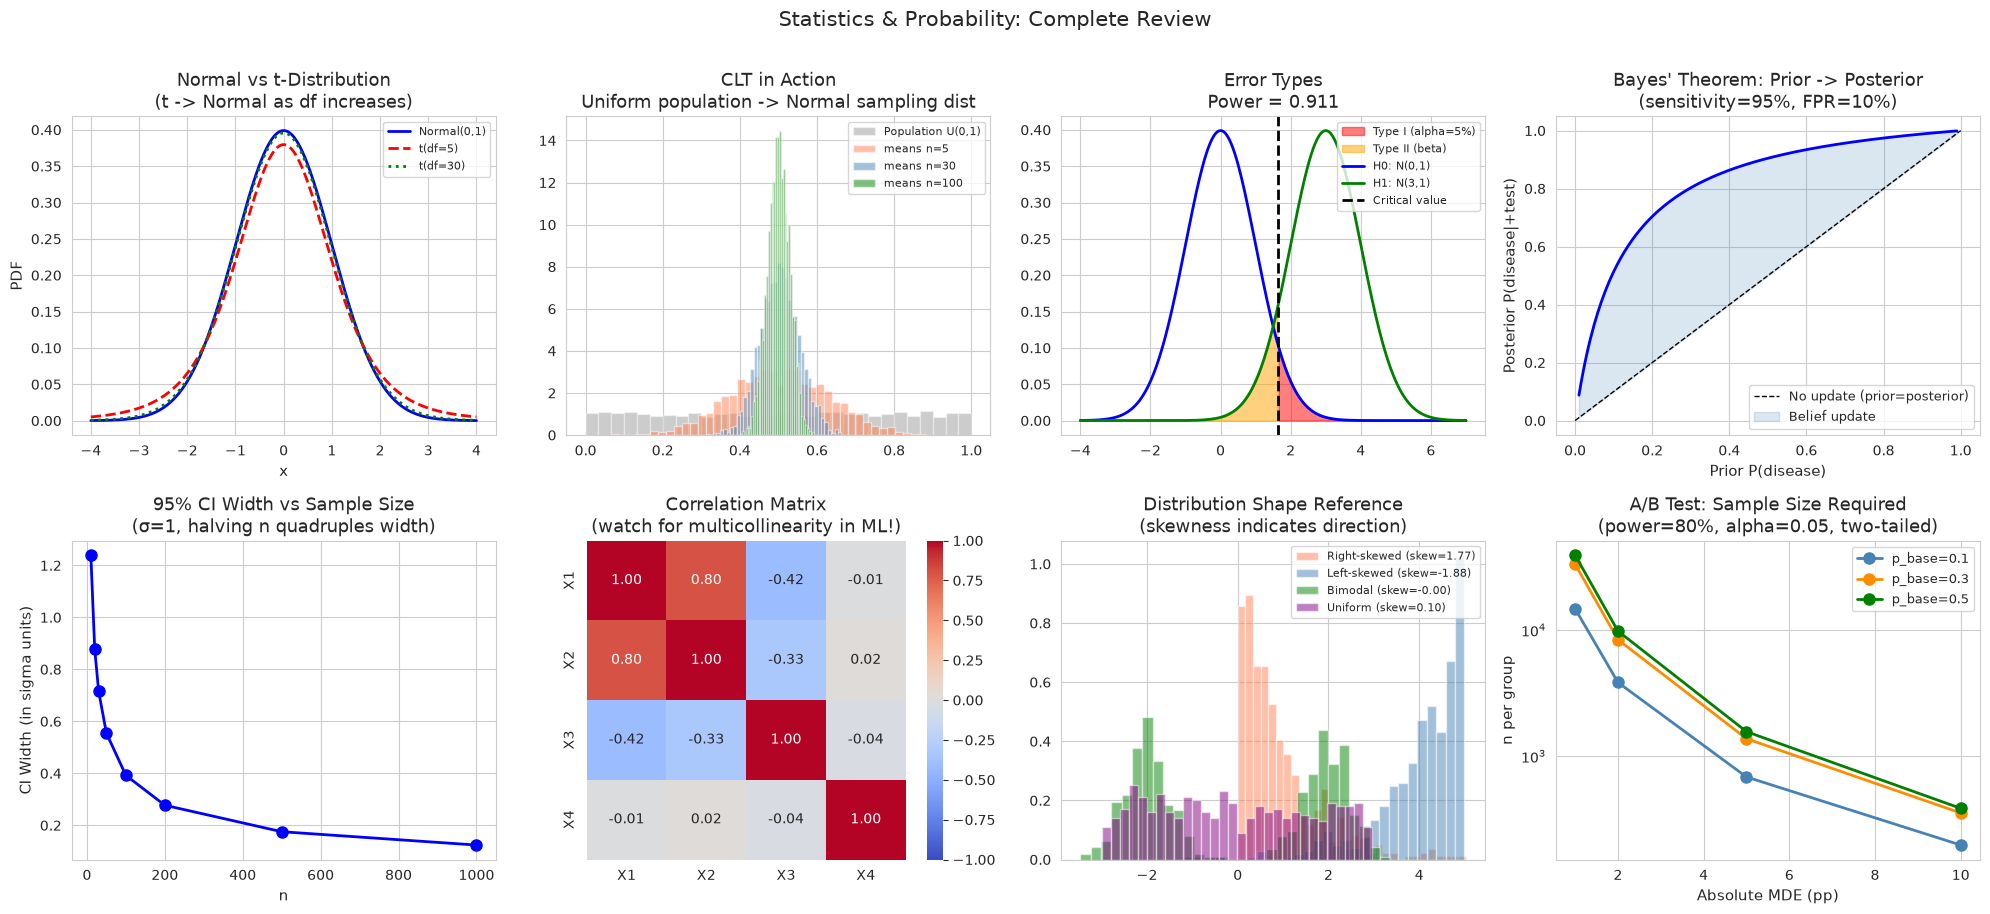


Notebook complete! All 12 topics covered.
Good luck with your interviews!


In [16]:
# Final: Comprehensive Statistics Review Plot
np.random.seed(42)
fig, axes = plt.subplots(2, 4, figsize=(20, 9))

# 1. All distributions
x = np.linspace(-4, 4, 300)
axes[0,0].plot(x, norm.pdf(x), 'b-', lw=2, label='Normal(0,1)')
axes[0,0].plot(x, t_dist.pdf(x, df=5), 'r--', lw=2, label='t(df=5)')
axes[0,0].plot(x, t_dist.pdf(x, df=30), 'g:', lw=2, label='t(df=30)')
axes[0,0].set_title('Normal vs t-Distribution\n(t -> Normal as df increases)')
axes[0,0].legend(fontsize=8); axes[0,0].set_xlabel('x'); axes[0,0].set_ylabel('PDF')

# 2. CLT with different populations
x_range = np.linspace(0, 1, 100)
pop_uniform = np.random.uniform(0, 1, 100000)
means_5  = [np.mean(np.random.choice(pop_uniform, 5))  for _ in range(3000)]
means_30 = [np.mean(np.random.choice(pop_uniform, 30)) for _ in range(3000)]
means_100 = [np.mean(np.random.choice(pop_uniform, 100)) for _ in range(3000)]
axes[0,1].hist(pop_uniform[:3000], bins=30, alpha=0.4, density=True, color='gray', label='Population U(0,1)')
axes[0,1].hist(means_5, bins=40, alpha=0.5, density=True, color='coral', label='means n=5')
axes[0,1].hist(means_30, bins=40, alpha=0.5, density=True, color='steelblue', label='means n=30')
axes[0,1].hist(means_100, bins=40, alpha=0.5, density=True, color='green', label='means n=100')
axes[0,1].set_title('CLT in Action\nUniform population -> Normal sampling dist')
axes[0,1].legend(fontsize=8)

# 3. Type I/II error visualization
x = np.linspace(-4, 7, 400)
axes[0,2].fill_between(x, norm.pdf(x, 0, 1), where=(x > 1.65), alpha=0.5, color='red', label='Type I (alpha=5%)')
axes[0,2].fill_between(x, norm.pdf(x, 3, 1), where=(x <= 1.65), alpha=0.5, color='orange', label='Type II (beta)')
axes[0,2].plot(x, norm.pdf(x, 0, 1), 'b-', lw=2, label='H0: N(0,1)')
axes[0,2].plot(x, norm.pdf(x, 3, 1), 'g-', lw=2, label='H1: N(3,1)')
axes[0,2].axvline(1.65, color='black', lw=2, linestyle='--', label='Critical value')
power_val = 1 - norm.cdf(1.65, 3, 1)
axes[0,2].set_title(f'Error Types\nPower = {power_val:.3f}')
axes[0,2].legend(fontsize=8)

# 4. Bayesian updating
priors = np.linspace(0.01, 0.99, 200)
# P(positive test | disease=T) = 0.95, P(positive | no disease) = 0.10
like_ratio = 0.95 / 0.10
posteriors_bayes = (like_ratio * priors) / (like_ratio * priors + 1 - priors)
axes[0,3].plot(priors, posteriors_bayes, 'b-', lw=2)
axes[0,3].plot([0,1],[0,1], 'k--', lw=1, label='No update (prior=posterior)')
axes[0,3].fill_between(priors, priors, posteriors_bayes, alpha=0.2, color='steelblue', label='Belief update')
axes[0,3].set_title("Bayes' Theorem: Prior -> Posterior\n(sensitivity=95%, FPR=10%)")
axes[0,3].set_xlabel('Prior P(disease)'); axes[0,3].set_ylabel('Posterior P(disease|+test)')
axes[0,3].legend(fontsize=9)

# 5. Confidence interval width vs n
ns = np.array([10, 20, 30, 50, 100, 200, 500, 1000])
ci_widths = 2 * 1.96 / np.sqrt(ns)
axes[1,0].plot(ns, ci_widths, 'bo-', lw=2, markersize=8)
axes[1,0].set_title('95% CI Width vs Sample Size\n(σ=1, halving n quadruples width)')
axes[1,0].set_xlabel('n'); axes[1,0].set_ylabel('CI Width (in sigma units)')

# 6. Correlation matrix pitfall
n = 200
x1 = np.random.normal(0, 1, n)
x2 = 0.8*x1 + 0.6*np.random.normal(0, 1, n)
x3 = -0.5*x1 + np.random.normal(0, 1, n)
x4 = np.random.normal(0, 1, n)  # independent
df_corr = pd.DataFrame({'X1': x1, 'X2': x2, 'X3': x3, 'X4': x4})
corr = df_corr.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=axes[1,1], square=True)
axes[1,1].set_title('Correlation Matrix\n(watch for multicollinearity in ML!)')

# 7. Distribution shapes quick ref
shapes = {
    'Right-skewed': np.random.exponential(1, 500),
    'Left-skewed': -np.random.exponential(1, 500) + 5,
    'Bimodal': np.concatenate([np.random.normal(-2, 0.5, 250), np.random.normal(2, 0.5, 250)]),
    'Uniform': np.random.uniform(-3, 3, 500),
}
colors = ['coral', 'steelblue', 'green', 'purple']
for (name, data), color in zip(shapes.items(), colors):
    from scipy.stats import skew as compute_skew
    axes[1,2].hist(data, bins=30, alpha=0.5, density=True, color=color,
                   label=f'{name} (skew={compute_skew(data):.2f})')
axes[1,2].set_title('Distribution Shape Reference\n(skewness indicates direction)')
axes[1,2].legend(fontsize=8)

# 8. Sample size for proportions
p_values = [0.1, 0.3, 0.5, 0.7, 0.9]
effects = np.array([0.01, 0.02, 0.05, 0.10])
from scipy.stats import norm as norm_dist2
for p_base, color in zip([0.1, 0.3, 0.5], ['steelblue', 'darkorange', 'green']):
    ns_req = []
    for eff in effects:
        p2 = p_base + eff
        if p2 > 1: ns_req.append(np.nan); continue
        z_a, z_b = norm_dist2.ppf(0.975), norm_dist2.ppf(0.80)
        n_r = ((z_a + z_b)**2 * (p_base*(1-p_base) + p2*(1-p2))) / eff**2
        ns_req.append(int(np.ceil(n_r)))
    axes[1,3].plot(effects*100, ns_req, 'o-', lw=2, color=color,
                   label=f'p_base={p_base}', markersize=8)
axes[1,3].set_title('A/B Test: Sample Size Required\n(power=80%, alpha=0.05, two-tailed)')
axes[1,3].set_xlabel('Absolute MDE (pp)'); axes[1,3].set_ylabel('n per group')
axes[1,3].legend(fontsize=9)
axes[1,3].set_yscale('log')

plt.suptitle('Statistics & Probability: Complete Review', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()
print("\nNotebook complete! All 12 topics covered.")
print("Good luck with your interviews!")